In [180]:
# legacy_enriching_v2 — CELL E1: Load structural ROIs

import pandas as pd
from pathlib import Path

BASE    = Path("/Users/davekokel/Projects/carp_v2")
WORKING = BASE / "seed_kits" / "legacy_wrangling" / "working"

struct_path = WORKING / "legacy_roi_structural_v2_mount_linked.csv"
df = pd.read_csv(struct_path)

df.shape, df.columns.tolist()
df.head()

,date_experiment,fish,roi_rel,roi_name,roi_tiffs,roi_dir,dataset,mount_dir_norm,date_mount,mount_id,...,Date imaged,Time placed in scope,Start of imaging time,End of imaging time,Imaged Locations,Unique Targets with blanks,Unique Targets,Data location,parent_female,parent_male
0,20250428_mem_histone,fish1_72hpf,roi1_tail,roi1_tail,3206,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,/abcabc/Korra_Foundation/20250428_mem_histone/...,2025-04-28,NaN,...,2025-04-28,12:30:00,14:30:00,NaN,"spinal_cord, skin, muscle, tail, notochord, hi...",nuclei,nuclei,X:\abcabc\Korra_Foundation\20250428_mem_histon...,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301)
1,20250428_mem_histone,fish1_72hpf,roi2_hindbrain_spine,roi2_hindbrain_spine,9760,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,/abcabc/Korra_Foundation/20250428_mem_histone/...,2025-04-28,NaN,...,2025-04-28,12:30:00,14:30:00,NaN,"spinal_cord, skin, muscle, tail, notochord, hi...",nuclei,nuclei,X:\abcabc\Korra_Foundation\20250428_mem_histon...,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301)
2,20250429_mem_cytosol,fish1_24hpf,roi1,roi1,6873,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,/abcabc/Korra_Foundation/20250429_mem_cytosol/...,2025-04-29,NaN,...,2025-04-29,12:45:00,13:00:00,10:20 AM (day+1),brain,cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301)
3,20250429_mem_cytosol,fish1_24hpf,roi1_test,roi1_test,46,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,/abcabc/Korra_Foundation/20250429_mem_cytosol/...,2025-04-29,NaN,...,2025-04-29,12:45:00,13:00:00,10:20 AM (day+1),brain,cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301)
4,20250429_mem_cytosol,fish2_48hpf,roi1,roi1,3180,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,/abcabc/Korra_Foundation/20250429_mem_cytosol/...,2025-04-30,NaN,...,2025-04-30,23:30:00,12:00:00,17:00:00,"hindbrain, spinal_cord, skin, muscle",cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301)


In [181]:
# CELL E2: Load fish, constructs, tags, JRC, manual mapper, injection mapping

RAW      = BASE / "seed_kits" / "legacy_wrangling" / "raw"
AUTOLOAD = BASE / "seed_kits" / "2025-11-15-121231-autoload"

fish_path       = AUTOLOAD / "fish.xlsx"
constructs_path = AUTOLOAD / "constructs_plasmid.csv"
tags_path       = AUTOLOAD / "tags.xlsx"

inj_plasmid_path = RAW / "Unique_injected_plasmid__preview_dqm.xlsx"
inj_rna_path     = RAW / "Unique_injected_rna__preview_dqm.xlsx"
jrc_path         = RAW / "plasmids_janelia_googlesheet.xlsx"
manual_map_path  = RAW / "roi_missing_parents_for_manual_mapping_DQM_CNH (1).csv"

# 👉 parent-name map (this is the missing piece)
parent_map_path  = RAW / "Unique_parent_names__mom_dad_combined__preview_dqm.xlsx"

df_fish       = pd.read_excel(fish_path)
df_constructs = pd.read_csv(constructs_path)
df_tags       = pd.read_excel(tags_path)
df_inj_plasm  = pd.read_excel(inj_plasmid_path)
df_inj_rna    = pd.read_excel(inj_rna_path)
df_jrc        = pd.read_excel(jrc_path)
df_map_manual = pd.read_csv(manual_map_path)

# 👇 this was missing
df_parent_map = pd.read_excel(parent_map_path)

df.shape, df_fish.shape, df_constructs.shape, df_tags.shape, df_jrc.shape, df_parent_map.shape
df.head()

,date_experiment,fish,roi_rel,roi_name,roi_tiffs,roi_dir,dataset,mount_dir_norm,date_mount,mount_id,...,Date imaged,Time placed in scope,Start of imaging time,End of imaging time,Imaged Locations,Unique Targets with blanks,Unique Targets,Data location,parent_female,parent_male
0,20250428_mem_histone,fish1_72hpf,roi1_tail,roi1_tail,3206,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,/abcabc/Korra_Foundation/20250428_mem_histone/...,2025-04-28,NaN,...,2025-04-28,12:30:00,14:30:00,NaN,"spinal_cord, skin, muscle, tail, notochord, hi...",nuclei,nuclei,X:\abcabc\Korra_Foundation\20250428_mem_histon...,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301)
1,20250428_mem_histone,fish1_72hpf,roi2_hindbrain_spine,roi2_hindbrain_spine,9760,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,/abcabc/Korra_Foundation/20250428_mem_histone/...,2025-04-28,NaN,...,2025-04-28,12:30:00,14:30:00,NaN,"spinal_cord, skin, muscle, tail, notochord, hi...",nuclei,nuclei,X:\abcabc\Korra_Foundation\20250428_mem_histon...,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301)
2,20250429_mem_cytosol,fish1_24hpf,roi1,roi1,6873,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,/abcabc/Korra_Foundation/20250429_mem_cytosol/...,2025-04-29,NaN,...,2025-04-29,12:45:00,13:00:00,10:20 AM (day+1),brain,cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301)
3,20250429_mem_cytosol,fish1_24hpf,roi1_test,roi1_test,46,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,/abcabc/Korra_Foundation/20250429_mem_cytosol/...,2025-04-29,NaN,...,2025-04-29,12:45:00,13:00:00,10:20 AM (day+1),brain,cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301)
4,20250429_mem_cytosol,fish2_48hpf,roi1,roi1,3180,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,/abcabc/Korra_Foundation/20250429_mem_cytosol/...,2025-04-30,NaN,...,2025-04-30,23:30:00,12:00:00,17:00:00,"hindbrain, spinal_cord, skin, muscle",cytosol,cytosol,X:\abcabc\Korra_Foundation\20250429_mem_cytoso...,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301)


In [182]:
# cell 2b # Build clean inj_plasm_map and inj_rna_map from the curated Unique_* tables
# Build clean inj_plasm_map and inj_rna_map from the curated Unique_* tables
# No JRC-based aliasing here: fluors come only via basecodes.

import math

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

# ---------- plasmid injection map ----------

PLASM_RAW_COL  = "injected_plasmid"      # adjust if your column names differ
PLASM_BASE_COL = "plasmid_base_code"

pl = df_inj_plasm.copy()
pl[PLASM_RAW_COL]  = pl[PLASM_RAW_COL].astype(str).str.strip()
pl[PLASM_BASE_COL] = pl[PLASM_BASE_COL].astype(str).str.strip()

inj_plasm_map = {}
for _, row in pl.iterrows():
    raw  = row[PLASM_RAW_COL]
    base = row[PLASM_BASE_COL]
    if is_blank(raw) or is_blank(base):
        continue
    inj_plasm_map.setdefault(raw, set()).add(base)

inj_plasm_map = {k: ",".join(sorted(v)) for k, v in inj_plasm_map.items()}

# ---------- RNA injection map (this is the critical one) ----------

RNA_RAW_COL  = "injected_rna"           # adjust if needed
RNA_BASE_COL = "plasmid_base_code"

rn = df_inj_rna.copy()
rn[RNA_RAW_COL]  = rn[RNA_RAW_COL].astype(str).str.strip()
rn[RNA_BASE_COL] = rn[RNA_BASE_COL].astype(str).str.strip()

inj_rna_map = {}
for _, row in rn.iterrows():
    raw  = row[RNA_RAW_COL]
    base = row[RNA_BASE_COL]
    if is_blank(raw) or is_blank(base):
        continue
    inj_rna_map.setdefault(raw, set()).add(base)

inj_rna_map = {k: ",".join(sorted(v)) for k, v in inj_rna_map.items()}

# quick sanity check: what do we map for 2xCox8A:mSG?
print("inj_rna_map['2xCox8A:mSG'] =", inj_rna_map.get("2xCox8A:mSG"))



inj_rna_map['2xCox8A:mSG'] = MGCO-01


In [183]:
# DEBUG HELPER: inspect ROIs across stages (safe for missing columns and combo filters)

import pandas as pd

def show_roi(
    stage: str,
    roi_pattern: str | None = None,
    fluor_combo: str | None = None,
    max_rows: int = 10,
) -> None:
    """
    Print a snapshot of ROI rows at a given stage.

    - roi_pattern: substring to match in roi_dir (case-insensitive)
    - fluor_combo: substring to match in all_fluor_organelles (case-insensitive)
    Safe to call at any stage; only shows columns that currently exist.
    """

    if "roi_dir" not in df.columns:
        print(f"\n===== {stage} — df has no 'roi_dir' column yet; nothing to show. =====")
        return

    mask = pd.Series(True, index=df.index)

    if roi_pattern:
        mask &= df["roi_dir"].astype(str).str.contains(roi_pattern, case=False, na=False)

    if fluor_combo and "all_fluor_organelles" in df.columns:
        mask &= df["all_fluor_organelles"].astype(str).str.contains(fluor_combo, case=False, na=False)
    elif fluor_combo and "all_fluor_organelles" not in df.columns:
        print(f"\n[WARN] Requested fluor_combo filter '{fluor_combo}', "
              f"but 'all_fluor_organelles' is not in df.columns at this stage.")

    # columns we would like to see, if present
    desired_cols = [
        "roi_dir",
        "date_experiment",
        # parents / genotype
        "parent_female", "parent_male",
        "genotype_base_codes", "genotype_allele_codes",
        # raw injection text
        "additional plasmids injected",
        "additional mRNAs injected",
        "manual_injection_plasmid_codes",
        # resolved basecodes
        "treatment_plasmid_base_codes",
        "treatment_rna_base_codes",
        # fusions / localizations
        "genotype_marker_fusion_labels",
        "genotype_marker_localizations",
        "genotype_marker_fluor_loc_labels",
        "treatment_marker_fusion_labels",
        "treatment_marker_localizations",
        "treatment_marker_fluor_loc_labels",
        # rollups
        "all_unique_organelles",
        "all_fluor_organelles",
    ]

    cols = [c for c in desired_cols if c in df.columns]

    n_rows = int(mask.sum())
    print(f"\n===== {stage} — roi_pattern={roi_pattern!r}, "
          f"fluor_combo={fluor_combo!r}, rows={n_rows}, cols_shown={len(cols)} =====")

    if not cols:
        print("No desired columns exist yet at this stage.")
        return

    if n_rows == 0:
        print("(no rows matching filters)")
        return

    sub = df.loc[mask, cols].copy()
    display(sub.head(max_rows))
show_roi("after E2b (load + inj maps)")


===== after E2b (load + inj maps) — roi_pattern=None, fluor_combo=None, rows=1077, cols_shown=6 =====


,roi_dir,date_experiment,parent_female,parent_male,additional plasmids injected,additional mRNAs injected
0,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250428_mem_histone,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301),NaN,mScarlet3-S2:H2B
1,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250428_mem_histone,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301),NaN,mScarlet3-S2:H2B
2,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:mGold2s,NaN
3,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:mGold2s,NaN
4,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:mGold2s,NaN
5,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,ef1a:mGold2s,NaN
6,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,ef1a:mGold2s,NaN
7,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,ef1a:mGold2s,NaN
8,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,ef1a:mGold2s,NaN
9,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,ef1a:mGold2s,NaN


In [184]:
# CELL E3: Fill missing parents & manual injections using ROI mapper, ignoring skittles

import math
import re

df_map = df_map_manual.copy()

# normalize mapper columns
df_map["roi_dir"]            = df_map["roi_dir"].astype(str).str.strip()
df_map["slug"]               = df_map["slug"].astype(str).str.strip()
df_map["mother_fish_manual"] = df_map["mother_fish_manual"].astype(str).str.strip()
df_map["father_fish_manual"] = df_map["father_fish_manual"].astype(str).str.strip()
df_map["injection plasmid"]  = df_map["injection plasmid"].astype(str).str.strip()

# Ignore skittles rows in mapper
skit_mask = df_map["slug"].str.contains("skittle", case=False, na=False)
df_map_use = df_map.loc[~skit_mask].copy()

def norm_path(p: str) -> str | None:
    if p is None or (isinstance(p, float) and pd.isna(p)):
        return None
    s = str(p).replace("\\", "/")
    s = re.sub(r"^[A-Za-z]:", "", s)  # strip X: drive
    s = s.replace("/clusterfs/vast", "")
    s = s.replace("/clusterfs/nvme", "")
    s = s.replace("/clusterfs/nvme2", "")
    s = re.sub(r"/+", "/", s)
    return s.rstrip("/")

df["roi_dir_norm"]          = df["roi_dir"].apply(norm_path)
df_map_use["roi_dir_norm"]  = df_map_use["roi_dir"].apply(norm_path)

def is_blank(val) -> bool:
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

# merge manual info
df = df.merge(
    df_map_use[["roi_dir_norm","mother_fish_manual","father_fish_manual","injection plasmid"]],
    on="roi_dir_norm",
    how="left",
    suffixes=("", "_manual"),
)

# fill parents where missing
df["parent_female"] = df.apply(
    lambda r: (
        r["parent_female"]
        if not is_blank(r.get("parent_female"))
        else (r["mother_fish_manual"] if not is_blank(r.get("mother_fish_manual")) else None)
    ),
    axis=1,
)

df["parent_male"] = df.apply(
    lambda r: (
        r["parent_male"]
        if not is_blank(r.get("parent_male"))
        else (r["father_fish_manual"] if not is_blank(r.get("father_fish_manual")) else None)
    ),
    axis=1,
)

# stash manual injection info for later use in treatment mapping
df["manual_injection_plasmid_codes"] = df.apply(
    lambda r: r["injection plasmid"] if not is_blank(r.get("injection plasmid")) else None,
    axis=1,
)

# normalize 'nan' strings to None
for col in ["parent_female", "parent_male", "manual_injection_plasmid_codes"]:
    df[col] = df[col].apply(lambda v: None if is_blank(v) else str(v).strip())

# quick sanity check
df[["roi_dir","parent_female","parent_male","manual_injection_plasmid_codes"]].head()

show_roi("after E3 (load + inj maps)")


===== after E3 (load + inj maps) — roi_pattern=None, fluor_combo=None, rows=1077, cols_shown=7 =====


,roi_dir,date_experiment,parent_female,parent_male,additional plasmids injected,additional mRNAs injected,manual_injection_plasmid_codes
0,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250428_mem_histone,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301),NaN,mScarlet3-S2:H2B,None
1,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250428_mem_histone,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301),NaN,mScarlet3-S2:H2B,None
2,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:mGold2s,NaN,None
3,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:mGold2s,NaN,None
4,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:2xLynk:tdmSG(J) (F2 of allele 301),ef1a:mGold2s,NaN,None
5,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,ef1a:mGold2s,NaN,None
6,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,ef1a:mGold2s,NaN,None
7,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,ef1a:mGold2s,NaN,None
8,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,ef1a:mGold2s,NaN,None
9,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,ef1a:mGold2s,NaN,None


In [185]:
# CELL E4: infer genotype_base_codes and genotype_allele_codes from parents (multi-base, in-place)

import math

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

# df_parent_map should already be loaded in CELL E2 with columns:
# ['parent_fish_name', 'plasmid_base_code', 'allele']

pmap = (
    df_parent_map
    .assign(
        parent_fish_name=lambda d: d["parent_fish_name"].astype(str).str.strip(),
        plasmid_base_code=lambda d: d["plasmid_base_code"].astype(str).str.strip(),
        allele=lambda d: d["allele"].astype(str).str.strip(),
    )
)

# parent_name -> list[(base, allele)]
parent_to_records = (
    pmap.groupby("parent_fish_name")
        .apply(lambda sub: [(row["plasmid_base_code"], row["allele"]) for _, row in sub.iterrows()])
        .to_dict()
)

print("[E4] parent_to_records keys (sample):", list(parent_to_records.keys())[:10], "...")

def infer_bases_for_row(row):
    """Return (bases, allele_codes) inferred from parent_female / parent_male."""
    bases = []
    allele_codes = []

    for parent_col in ("parent_female", "parent_male"):
        name = (row.get(parent_col) or "").strip()
        if not name:
            continue
        for base, allele in parent_to_records.get(name, []):
            base = (base or "").strip()
            allele = (allele or "").strip()
            if not base:
                continue
            if base not in bases:
                bases.append(base)
            if allele:
                acode = f"{base}:{allele}"
                if acode not in allele_codes:
                    allele_codes.append(acode)

    return bases, allele_codes

changed_rows = 0

# Ensure columns exist
if "genotype_base_codes" not in df.columns:
    df["genotype_base_codes"] = None
if "genotype_allele_codes" not in df.columns:
    df["genotype_allele_codes"] = None

for idx, row in df.iterrows():
    bases, allele_codes = infer_bases_for_row(row)
    if not bases:
        continue

    # Always recompute from parents for consistency
    df.at[idx, "genotype_base_codes"] = ",".join(sorted(bases))
    df.at[idx, "genotype_allele_codes"] = (
        ",".join(sorted(allele_codes)) if allele_codes else None
    )
    changed_rows += 1

print(f"[E4] filled genotype_base_codes for {changed_rows} ROI row(s).")

[E4] parent_to_records keys (sample): ['Abe (F2 of allele 309)', 'Ben (F2 of allele 310)', 'Chris (F1 of allele 317)', 'Dennis (F2 of allele 318)', 'Isaac (F2 of allele 314)', 'Jim (F2 of allele 316)', 'Ken (F2 of allele 320)', 'Liam (F2 of allele 321)', 'MGCO35 (F1 of allele 336)', 'casper/rnf'] ...
[E4] filled genotype_base_codes for 839 ROI row(s).


/var/folders/29/cdrb2nrn01s4d1_n6gvxy5j80000gn/T/ipykernel_392/1728378429.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda sub: [(row["plasmid_base_code"], row["allele"]) for _, row in sub.iterrows()])


In [186]:
print("genotype_base_codes" in df.columns)
show_roi("after E4", roi_pattern="20251013_mem-histone")

True

===== after E4 — roi_pattern='20251013_mem-histone', fluor_combo=None, rows=15, cols_shown=9 =====


,roi_dir,date_experiment,parent_female,parent_male,genotype_base_codes,genotype_allele_codes,additional plasmids injected,additional mRNAs injected,manual_injection_plasmid_codes
357,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251013_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None
358,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251013_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None
359,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251013_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None
360,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251013_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None
361,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251013_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None
362,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251013_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None
363,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251013_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None
364,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251013_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None
365,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251013_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None
949,/clusterfs/vast/abcabc/Aang_Foundation/2025101...,20251013_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None


In [187]:
# ======================================================
# CELL 5 — Map treatment injections to base codes
#          using Unique_injected_* mappers only
# ======================================================

import math

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

# ---- plasmids: map additional plasmids + manual injection codes via inj_plasm_map ----

def map_plasmids_exact(text: object, manual: object) -> str | None:
    """
    Map 'additional plasmids injected' and 'manual_injection_plasmid_codes'
    to basecodes using inj_plasm_map (Unique_injected_plasmid) and the
    manual codes (which are already basecodes).
    """
    bases = []

    # 1) from the imaging sheet field
    if not is_blank(text):
        key = str(text).strip()
        mapped = inj_plasm_map.get(key)
        if mapped:
            for c in mapped.split(","):
                c = c.strip()
                if c and c not in bases:
                    bases.append(c)

    # 2) from manual_injection_plasmid_codes (already basecodes)
    if not is_blank(manual):
        for c in str(manual).split(","):
            c = c.strip()
            if c and c not in bases:
                bases.append(c)

    return ",".join(bases) if bases else None

# ---- RNAs: map additional mRNAs injected via inj_rna_map ----

def map_rnas_exact(text: object) -> str | None:
    """
    Map 'additional mRNAs injected' to basecodes using inj_rna_map
    (Unique_injected_rna). No token splitting; full string must match.
    """
    if is_blank(text):
        return None
    key = str(text).strip()
    if not key:
        return None
    mapped = inj_rna_map.get(key)
    return mapped if mapped else None

PLASM_INJ_COL = "additional plasmids injected"
RNA_INJ_COL   = "additional mRNAs injected"

# Apply mappings
df["treatment_plasmid_base_codes"] = df.apply(
    lambda r: map_plasmids_exact(
        r.get(PLASM_INJ_COL),
        r.get("manual_injection_plasmid_codes"),
    ),
    axis=1,
)

df["treatment_rna_base_codes"] = df[RNA_INJ_COL].apply(map_rnas_exact)

# Quick sanity check on mem-mito
show_roi("after 5 (exact Unique_* mapping)", roi_pattern="20251106_mem-mito")


===== after 5 (exact Unique_* mapping) — roi_pattern='20251106_mem-mito', fluor_combo=None, rows=26, cols_shown=11 =====


,roi_dir,date_experiment,parent_female,parent_male,genotype_base_codes,genotype_allele_codes,additional plasmids injected,additional mRNAs injected,manual_injection_plasmid_codes,treatment_plasmid_base_codes,treatment_rna_base_codes
412,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
413,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
414,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
415,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
416,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
417,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
418,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
419,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
420,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
421,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01


In [188]:
# CELL 5a: build constructs + tags mapping (cons_small, tags_map, code_to_orgs)

import math
import re

# df_constructs: from constructs_plasmid.csv (already loaded in CELL E2)
# df_tags:       from tags.xlsx (already loaded in CELL E2)
# df_tags columns: ['nickname', 'localization', 'note', 'citation_link', 'aliases']

# Base constructs mapping: plasmid_base_code → fluor_code, tag_code, tag_pos
cons_small = (
    df_constructs[["plasmid_code", "fluor_code", "tag_code", "tag_pos"]]
    .rename(columns={"plasmid_code": "plasmid_base_code"})
    .copy()
)
cons_small["plasmid_base_code"] = cons_small["plasmid_base_code"].astype(str).str.strip()
cons_small["fluor_code"]        = cons_small["fluor_code"].astype(str).str.strip()
cons_small["tag_code"]          = cons_small["tag_code"].astype(str).str.strip()
cons_small["tag_pos"]           = cons_small["tag_pos"].astype(str).str.strip()

# Tags mapping: nickname → tag_code, localization (organelle)
tags_map = (
    df_tags[["nickname", "localization"]]
    .rename(columns={"nickname": "tag_code"})
    .assign(
        tag_code    = lambda d: d["tag_code"].astype(str).str.strip(),
        localization= lambda d: d["localization"].astype(str).str.strip(),
    )
)

# Optional: build a mapping from plasmid_base_code → set of localizations
cons_loc = (
    cons_small.merge(tags_map, how="left", on="tag_code")
    [["plasmid_base_code", "localization"]]
)

code_to_orgs: dict[str, set[str]] = {}

for _, row in cons_loc.iterrows():
    code = (row["plasmid_base_code"] or "")
    code = str(code).strip()
    loc  = row.get("localization", "")
    loc  = "" if (loc is None or (isinstance(loc, float) and math.isnan(loc))) else str(loc).strip()

    if not code:
        continue
    if code not in code_to_orgs:
        code_to_orgs[code] = set()
    if loc:
        code_to_orgs[code].add(loc)

print("[CELL 5a] cons_small:", cons_small.shape)
print("[CELL 5a] tags_map:", tags_map.shape)
print("[CELL 5a] code_to_orgs size:", len(code_to_orgs))

[CELL 5a] cons_small: (286, 4)
[CELL 5a] tags_map: (10, 2)
[CELL 5a] code_to_orgs size: 216


In [189]:
# CELL 5b: optional date-aware RNA resolver (only if you really need it)

import re
import math

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

def normalize_inj_text(text: object) -> list[str]:
    """
    Split the 'additional mRNAs injected' free text into cleaned tokens.
    This must match the semantics used in the exact Unique_* mapping.
    """
    if text is None or (isinstance(text, float) and math.isnan(text)):
        return []
    s = str(text).strip()
    if not s:
        return []
    tokens = re.split(r"[;,]", s)
    return [t.strip() for t in tokens if t.strip()]

# inj_rna_map should exist from Cell 5; if not, bail out
if "inj_rna_map" not in globals():
    print("[5b] inj_rna_map not found; did you run Cell 5 first? Skipping 5b.")
else:
    def resolve_rna_for_slug(text: object, slug: str):
        """
        Resolve additional mRNAs injected (text) to base codes using inj_rna_map.

        Currently we do NOT do any fancy date-aware disambiguation. If a token
        maps to multiple basecodes in inj_rna_map, we keep them all and mark
        the row ambiguous.
        """
        tokens = normalize_inj_text(text)
        if not tokens:
            return None, False

        bases = []
        ambiguous = False

        for t in tokens:
            if t not in inj_rna_map:
                continue
            raw = inj_rna_map[t]
            # raw is a comma-separated string of basecodes
            codes = [c.strip() for c in str(raw).split(",") if c.strip()]
            if len(codes) > 1:
                ambiguous = True
            for c in codes:
                if c not in bases:
                    bases.append(c)

        return (",".join(bases) if bases else None), ambiguous

    rna_codes = []
    rna_ambig = []

    for _, row in df.iterrows():
        codes, amb = resolve_rna_for_slug(
            row.get("additional mRNAs injected"),
            row.get("date_experiment"),
        )
        rna_codes.append(codes)
        rna_ambig.append(bool(amb))

    df["treatment_rna_base_codes"] = df["treatment_rna_base_codes"].where(
        ~pd.Series(df["treatment_rna_base_codes"]).isna(),
        pd.Series(rna_codes),
    )
    df["treatment_rna_mapping_ambiguous"] = rna_ambig

    print("[5b] filled treatment_rna_base_codes for",
          sum(not is_blank(x) for x in rna_codes), "row(s).")
    print("[5b] rows with ambiguous RNA mapping:",
          sum(rna_ambig))

[5b] filled treatment_rna_base_codes for 497 row(s).
[5b] rows with ambiguous RNA mapping: 0


In [190]:
# CELL 5c: normalize 'pDQM005(302)' style genotype codes into base & allele

import re
import math

def split_base_allele(val: object):
    """
    Take strings like 'pDQM005(302)' and return ('pDQM005', 'pDQM005:302').
    Otherwise return (None, None) and leave the row alone.
    """
    if val is None:
        return (None, None)
    s = str(val).strip()
    if not s:
        return (None, None)
    m = re.match(r"^(pDQM\d+)\((\d+)\)$", s)
    if not m:
        return (None, None)
    base = m.group(1)
    allele = m.group(2)
    return base, f"{base}:{allele}"

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

# If genotype_base_codes doesn't exist yet, do nothing
if "genotype_base_codes" not in df.columns:
    print("[normalize_base_allele] genotype_base_codes not in df.columns; skipping.")
else:
    mask = df["genotype_base_codes"].astype(str).str.match(r"^pDQM\d+\(\d+\)$", na=False)

    changed = 0
    for idx, row in df[mask].iterrows():
        gb = row["genotype_base_codes"]
        base, allele_code = split_base_allele(gb)
        if not base:
            continue
        old_gb = str(row.get("genotype_base_codes") or "").strip()
        old_ga = str(row.get("genotype_allele_codes") or "").strip()
        # only overwrite if allele fields are blank or identical to raw
        if old_ga in ("", old_gb):
            df.at[idx, "genotype_base_codes"] = base
            df.at[idx, "genotype_allele_codes"] = allele_code
            changed += 1

    print(f"[normalize_base_allele] normalized {changed} genotype row(s) like 'pDQM005(302)' → base + allele.")

[normalize_base_allele] normalized 0 genotype row(s) like 'pDQM005(302)' → base + allele.


In [191]:
# CELL 6: Build constructs mapping (cons_small), tags_map, and fusion helpers

import pandas as pd

# cons_small: plasmid_base_code → fluor_code, tag_code, tag_pos
cons_small = (
    df_constructs[["plasmid_code","fluor_code","tag_code","tag_pos"]]
      .rename(columns={"plasmid_code": "plasmid_base_code"})
      .copy()
)
cons_small["plasmid_base_code"] = cons_small["plasmid_base_code"].astype(str).str.strip()

# tags_map: tag_code → localization
if "tag_code" in df_tags.columns:
    tag_code_col = "tag_code"
elif "nickname" in df_tags.columns:
    tag_code_col = "nickname"
else:
    raise RuntimeError("No tag_code or nickname column in tags.xlsx")

loc_cols = [c for c in df_tags.columns if c.lower() == "localization"]
if not loc_cols:
    raise RuntimeError("No localization column in tags.xlsx")
loc_col = loc_cols[0]

tags_map = df_tags[[tag_code_col, loc_col]].copy()
tags_map.columns = ["tag_code","localization"]
tags_map["tag_code"] = tags_map["tag_code"].astype(str).str.strip()

# ---------- helpers ----------

import math

def split_codes(val: object) -> list[str]:
    if val is None or (isinstance(val, float) and math.isnan(val)):
        return []
    s = str(val).strip()
    if not s:
        return []
    tokens = re.split(r"[;,]", s)
    return [t.strip() for t in tokens if t.strip()]

def agg_uniq(series: pd.Series) -> str | None:
    vals = []
    for x in series:
        if x is None or (isinstance(x, float) and math.isnan(x)):
            continue
        s = str(x).strip()
        if s:
            vals.append(s)
    if not vals:
        return None
    uniq = sorted(set(vals))
    return ",".join(uniq)

def _clean(val) -> str:
    """Return a clean string or '' for NaN/None."""
    if val is None or (isinstance(val, float) and math.isnan(val)):
        return ""
    return str(val).strip()

def make_fusion_label(row: pd.Series) -> str | None:
    fluor = _clean(row.get("fluor_code"))
    tag   = _clean(row.get("tag_code"))
    pos   = _clean(row.get("tag_pos"))
    if not fluor and not tag:
        return None
    if fluor and not tag:
        return fluor
    if not fluor and tag:
        return tag
    if fluor and tag and pos:
        return f"{fluor}::{tag}({pos})"
    return f"{fluor}::{tag}"

def fluor_loc_label(row: pd.Series) -> str | None:
    fluor = _clean(row.get("fluor_code"))
    loc   = _clean(row.get("localization"))
    if not fluor:
        return None
    if loc:
        return f"{fluor}({loc})"
    return fluor

def fusion_loc_label(row: pd.Series) -> str | None:
    fusion = make_fusion_label(row)
    if not fusion:
        return None
    loc = _clean(row.get("localization"))
    if loc:
        return f"{fusion}({loc})"
    return fusion

show_roi("after 6 (exact Unique_* mapping)", roi_pattern="20251106_mem-mito")


===== after 6 (exact Unique_* mapping) — roi_pattern='20251106_mem-mito', fluor_combo=None, rows=26, cols_shown=11 =====


,roi_dir,date_experiment,parent_female,parent_male,genotype_base_codes,genotype_allele_codes,additional plasmids injected,additional mRNAs injected,manual_injection_plasmid_codes,treatment_plasmid_base_codes,treatment_rna_base_codes
412,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
413,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
414,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
415,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
416,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
417,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
418,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
419,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
420,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01
421,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01


In [192]:
# CELL 7: Compute genotype & treatment marker fusions + localizations

# ---------- Genotype side ----------

# explode genotype_base_codes
gexp = (
    df[["roi_dir","genotype_base_codes"]]
    .copy()
)
gexp["code_list"] = gexp["genotype_base_codes"].apply(split_codes)
gexp = gexp.explode("code_list").rename(columns={"code_list": "plasmid_base_code"})
gexp["plasmid_base_code"] = gexp["plasmid_base_code"].astype(str).str.strip()
gexp = gexp[gexp["plasmid_base_code"] != ""]

# join to constructs + tags
gjoin = (
    gexp.merge(cons_small, how="left", on="plasmid_base_code")
        .merge(tags_map, how="left", on="tag_code")
)

gjoin["fusion_label"] = gjoin.apply(make_fusion_label, axis=1)
gjoin["fluor_loc"]    = gjoin.apply(fluor_loc_label, axis=1)
gjoin["fusion_loc"]   = gjoin.apply(fusion_loc_label, axis=1)

g_per_roi = (
    gjoin.groupby("roi_dir", as_index=False)
         .agg(
             genotype_marker_fluor_codes   = ("fluor_code", agg_uniq),
             genotype_marker_tag_codes     = ("tag_code", agg_uniq),
             genotype_marker_fusion_labels = ("fusion_label", agg_uniq),
             genotype_marker_localizations = ("localization", agg_uniq),
             genotype_marker_fluor_loc_labels  = ("fluor_loc", agg_uniq),
             genotype_marker_fusion_loc_labels = ("fusion_loc", agg_uniq),
         )
)

df = df.merge(g_per_roi, on="roi_dir", how="left")


# ---------- Treatment side ----------

def collect_all_treatment_codes(row: pd.Series) -> list[str]:
    codes = []
    codes.extend(split_codes(row.get("treatment_plasmid_base_codes")))
    codes.extend(split_codes(row.get("treatment_rna_base_codes")))
    seen = set()
    out  = []
    for c in codes:
        if c not in seen:
            seen.add(c)
            out.append(c)
    return out

texp = (
    df[["roi_dir","treatment_plasmid_base_codes","treatment_rna_base_codes"]]
    .copy()
)
texp["code_list"] = texp.apply(collect_all_treatment_codes, axis=1)
texp = texp.explode("code_list").rename(columns={"code_list": "plasmid_base_code"})
texp["plasmid_base_code"] = texp["plasmid_base_code"].astype(str).str.strip()
texp = texp[texp["plasmid_base_code"] != ""]

tjoin = (
    texp.merge(cons_small, how="left", on="plasmid_base_code")
         .merge(tags_map, how="left", on="tag_code")
)

tjoin["fusion_label"] = tjoin.apply(make_fusion_label, axis=1)
tjoin["fluor_loc"]    = tjoin.apply(fluor_loc_label, axis=1)
tjoin["fusion_loc"]   = tjoin.apply(fusion_loc_label, axis=1)

t_per_roi = (
    tjoin.groupby("roi_dir", as_index=False)
         .agg(
             treatment_marker_fluor_codes   = ("fluor_code", agg_uniq),
             treatment_marker_tag_codes     = ("tag_code", agg_uniq),
             treatment_marker_fusion_labels = ("fusion_label", agg_uniq),
             treatment_marker_localizations = ("localization", agg_uniq),
             treatment_marker_fluor_loc_labels  = ("fluor_loc", agg_uniq),
             treatment_marker_fusion_loc_labels = ("fusion_loc", agg_uniq),
         )
)

df = df.merge(t_per_roi, on="roi_dir", how="left")


# ---------- sanity check ----------
df[[
    "roi_dir",
    "genotype_base_codes",
    "genotype_marker_fusion_labels",
    "genotype_marker_localizations",
    "treatment_plasmid_base_codes",
    "treatment_rna_base_codes",
    "treatment_marker_fusion_labels",
    "treatment_marker_localizations",
]].head(25)

show_roi("after 7 (exact Unique_* mapping)", roi_pattern="20251106_mem-mito")


===== after 7 (exact Unique_* mapping) — roi_pattern='20251106_mem-mito', fluor_combo=None, rows=26, cols_shown=17 =====


,roi_dir,date_experiment,parent_female,parent_male,genotype_base_codes,genotype_allele_codes,additional plasmids injected,additional mRNAs injected,manual_injection_plasmid_codes,treatment_plasmid_base_codes,treatment_rna_base_codes,genotype_marker_fusion_labels,genotype_marker_localizations,genotype_marker_fluor_loc_labels,treatment_marker_fusion_labels,treatment_marker_localizations,treatment_marker_fluor_loc_labels
412,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria)
413,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria)
414,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria)
415,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria)
416,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria)
417,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria)
418,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria)
419,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria)
420,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria)
421,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria)


In [193]:
# CELL 8: Canonical organelle vocabulary + all_unique_organelles + all_fluor_organelles

import math
import re

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

def split_locs(val: object) -> list[str]:
    if is_blank(val):
        return []
    s = str(val).replace(";", ",")
    return [p.strip() for p in s.split(",") if p.strip()]

# ---- canonical organelle vocab ----

canonical_organelle_map = {
    "membrane": "membrane",
    "mem": "membrane",
    "plasma_membrane": "membrane",

    "nucleus": "nucleus",
    "nuclei": "nucleus",

    "mito": "mitochondria",
    "mitochondria": "mitochondria",

    "er": "ER",
    "endoplasmic_reticulum": "ER",

    "golgi": "golgi",

    "peroxi": "peroxisome",
    "peroxisome": "peroxisome",

    "lam": "lamellipodia",
    "lamellipodia": "lamellipodia",

    "actin": "actin",
    "f-actin": "actin",

    "histone": "histone",
    "chromatin": "histone",
}

def canonicalize_organelle(label: str) -> str:
    if not isinstance(label, str) or not label.strip():
        return ""
    low = label.strip().lower()
    if low in canonical_organelle_map:
        return canonical_organelle_map[low]
    for k, v in canonical_organelle_map.items():
        if k in low:
            return v
    return label.strip()

def combine_unique_lists(*args) -> list[str]:
    seen = set()
    out  = []
    for lst in args:
        for x in lst:
            if not x:
                continue
            if x not in seen:
                seen.add(x)
                out.append(x)
    return out

# ---- normalize genotype & treatment localizations ----

df["genotype_marker_localizations_norm"] = (
    df["genotype_marker_localizations"]
      .apply(lambda x: [canonicalize_organelle(t) for t in split_locs(x)])
)

df["treatment_marker_localizations_norm"] = (
    df["treatment_marker_localizations"]
      .apply(lambda x: [canonicalize_organelle(t) for t in split_locs(x)])
)

# ---- compute all_unique_organelles ----

def row_all_organelles(row):
    g = row.get("genotype_marker_localizations_norm", []) or []
    t = row.get("treatment_marker_localizations_norm", []) or []
    combined = combine_unique_lists(g, t)
    # canonicalize: unique + sorted
    combined = sorted(set(x for x in combined if x))
    return ",".join(combined) if combined else None

df["all_unique_organelles"] = df.apply(row_all_organelles, axis=1)

# ---- compute all_fluor_organelles from fluor_loc labels ONLY ----

def parse_fluor_loc_labels(val: object) -> list[str]:
    if val is None or (isinstance(val, float) and math.isnan(val)):
        return []
    s = str(val).strip()
    if not s:
        return []
    # split on commas/semicolons
    tokens = re.split(r"[;,]", s)
    out = []
    for tok in tokens:
        tok = tok.strip()
        if not tok:
            continue
        m = re.match(r"^(.*?)\((.*?)\)$", tok)
        if m:
            fluor = m.group(1).strip()
            org   = canonicalize_organelle(m.group(2).strip())
            out.append(f"{fluor}({org})")
        else:
            out.append(tok)
    return out

def row_all_fluor_organelles(row: pd.Series) -> str | None:
    g = parse_fluor_loc_labels(row.get("genotype_marker_fluor_loc_labels"))
    t = parse_fluor_loc_labels(row.get("treatment_marker_fluor_loc_labels"))
    combined = combine_unique_lists(g, t)
    combined = sorted(set(x for x in combined if x))
    return ",".join(combined) if combined else None

df["all_fluor_organelles"] = df.apply(row_all_fluor_organelles, axis=1)

# ---- quick sanity check ----
df[[
    "roi_dir",
    "genotype_marker_fusion_labels",
    "genotype_marker_localizations",
    "treatment_marker_fusion_labels",
    "treatment_marker_localizations",
    "all_unique_organelles",
    "all_fluor_organelles",
]].head(25)

show_roi("after 8 (exact Unique_* mapping)", roi_pattern="20251106_mem-mito")


===== after 8 (exact Unique_* mapping) — roi_pattern='20251106_mem-mito', fluor_combo=None, rows=26, cols_shown=19 =====


,roi_dir,date_experiment,parent_female,parent_male,genotype_base_codes,genotype_allele_codes,additional plasmids injected,additional mRNAs injected,manual_injection_plasmid_codes,treatment_plasmid_base_codes,treatment_rna_base_codes,genotype_marker_fusion_labels,genotype_marker_localizations,genotype_marker_fluor_loc_labels,treatment_marker_fusion_labels,treatment_marker_localizations,treatment_marker_fluor_loc_labels,all_unique_organelles,all_fluor_organelles
412,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
413,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
414,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
415,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
416,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
417,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
418,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
419,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
420,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
421,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(m

In [194]:
# CELL 8a — enforce histone localization for H2B-tagged constructs (fix mem-histone rows)

import re
import math

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

# 1) find plasmid codes that are H2B-tagged (should be pDQM133 etc.)
h2b_codes = set(
    df_constructs.loc[
        df_constructs["tag_code"].astype(str).str.strip().str.upper() == "H2B",
        "plasmid_code"
    ].astype(str).str.strip().tolist()
)

print("[E8b] H2B-tagged base codes:", sorted(h2b_codes))

if h2b_codes:
    # 2) ROIs whose genotype includes at least one H2B-tagged base code
    mask_h2b_geno = (
        df["genotype_base_codes"]
        .astype(str)
        .apply(lambda s: any(code in s.split(",") for code in h2b_codes))
    )

    print("[E8b] ROIs with H2B genotype:", mask_h2b_geno.sum())

    for idx, row in df[mask_h2b_geno].iterrows():
        # ---- genotype_marker_localizations ----
        locs = []
        if not is_blank(row.get("genotype_marker_localizations")):
            locs = [t.strip() for t in str(row["genotype_marker_localizations"]).split(",") if t.strip()]

        if "histone" not in locs:
            locs.append("histone")
        df.at[idx, "genotype_marker_localizations"] = ",".join(sorted(set(locs)))

        # ---- genotype_marker_fluor_loc_labels ----
        fluor_loc = []
        if not is_blank(row.get("genotype_marker_fluor_loc_labels")):
            fluor_loc = [t.strip() for t in str(row["genotype_marker_fluor_loc_labels"]).split(",") if t.strip()]

        # if we ever have a bare 'tdmScarlet3' in fluor_loc, upgrade it to tdmScarlet3(histone)
        fixed_fluor_loc = []
        for t in fluor_loc:
            m = re.match(r"^(tdmScarlet3(?:S2)?)$", t)
            if m:
                fixed_fluor_loc.append("tdmScarlet3(histone)")
            else:
                fixed_fluor_loc.append(t)
        if "tdmScarlet3(histone)" not in fixed_fluor_loc and any(
            "Scarlet" in t or "tdmScarlet3" in t for t in fluor_loc
        ):
            fixed_fluor_loc.append("tdmScarlet3(histone)")

        df.at[idx, "genotype_marker_fluor_loc_labels"] = ",".join(sorted(set(fixed_fluor_loc))) if fixed_fluor_loc else None

        # ---- all_unique_organelles ----
        all_orgs = []
        if not is_blank(row.get("all_unique_organelles")):
            all_orgs = [t.strip() for t in str(row["all_unique_organelles"]).split(",") if t.strip()]
        if "histone" not in all_orgs:
            all_orgs.append("histone")
        df.at[idx, "all_unique_organelles"] = ",".join(sorted(set(all_orgs)))

        # ---- all_fluor_organelles ----
        all_fl = []
        if not is_blank(row.get("all_fluor_organelles")):
            all_fl = [t.strip() for t in str(row["all_fluor_organelles"]).split(",") if t.strip()]

        # upgrade any bare tdmScarlet3 in the rollup
        fixed_all_fl = []
        for t in all_fl:
            m = re.match(r"^(tdmScarlet3(?:S2)?)$", t)
            if m:
                fixed_all_fl.append("tdmScarlet3(histone)")
            else:
                fixed_all_fl.append(t)
        if "tdmScarlet3(histone)" not in fixed_all_fl and any(
            "Scarlet" in t or "tdmScarlet3" in t for t in all_fl
        ):
            fixed_all_fl.append("tdmScarlet3(histone)")

        df.at[idx, "all_fluor_organelles"] = ",".join(sorted(set(fixed_all_fl))) if fixed_all_fl else None

# quick sanity check on the 20251020_mem-histone slug
show_roi("after 8a (H2B histone fix)", roi_pattern="20251020_mem-histone")

[E8b] H2B-tagged base codes: ['pDQM051', 'pDQM052', 'pDQM053', 'pDQM054', 'pDQM058', 'pDQM060', 'pDQM065', 'pDQM066', 'pDQM067', 'pDQM072', 'pDQM073', 'pDQM076', 'pDQM077', 'pDQM105', 'pDQM117', 'pDQM118', 'pDQM119', 'pDQM131', 'pDQM133', 'pDQM161', 'pDQM162', 'pDQM167', 'pDQM168']
[E8b] ROIs with H2B genotype: 110

===== after 8a (H2B histone fix) — roi_pattern='20251020_mem-histone', fluor_combo=None, rows=20, cols_shown=19 =====


,roi_dir,date_experiment,parent_female,parent_male,genotype_base_codes,genotype_allele_codes,additional plasmids injected,additional mRNAs injected,manual_injection_plasmid_codes,treatment_plasmid_base_codes,treatment_rna_base_codes,genotype_marker_fusion_labels,genotype_marker_localizations,genotype_marker_fluor_loc_labels,treatment_marker_fusion_labels,treatment_marker_localizations,treatment_marker_fluor_loc_labels,all_unique_organelles,all_fluor_organelles
378,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251020_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None,None,None,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane","tdmSG(membrane),tdmScarlet3(histone)",None,None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
379,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251020_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None,None,None,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane","tdmSG(membrane),tdmScarlet3(histone)",None,None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
380,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251020_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None,None,None,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane","tdmSG(membrane),tdmScarlet3(histone)",None,None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
381,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251020_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None,None,None,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane","tdmSG(membrane),tdmScarlet3(histone)",None,None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
382,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251020_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None,None,None,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane","tdmSG(membrane),tdmScarlet3(histone)",None,None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
383,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251020_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None,None,None,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane","tdmSG(membrane),tdmScarlet3(histone)",None,None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
384,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251020_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None,None,None,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane","tdmSG(membrane),tdmScarlet3(histone)",None,None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
385,/clusterfs/vast/abcabc/Korra_Foundation/202510...,20251020_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None,None,None,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane","tdmSG(membrane),tdmScarlet3(histone)",None,None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
971,/clusterfs/vast/abcabc/Aang_Foundation/2025102...,20251020_mem-histone,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),"pDQM005,pDQM133","pDQM005:301,pDQM133:324",NaN,NaN,None,None,None,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane","tdmSG(membrane),tdmScarlet3(histone)",None,None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3

In [195]:
# CELL 8c — Recompute organelle rollups from fluor_loc labels + QA
import math
import re

# ── helpers ────────────────────────────────────────────────────────────────
def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

def split_items(val: object) -> list[str]:
    if is_blank(val):
        return []
    s = str(val).replace(";", ",")
    return [t.strip() for t in s.split(",") if t.strip()]

# If canonicalize_organelle already exists from an earlier cell, reuse it.
# Otherwise, define a simple identity version.
if "canonicalize_organelle" not in globals():
    def canonicalize_organelle(label: str) -> str:
        if not isinstance(label, str):
            return ""
        return label.strip()

def parse_fluor_loc_labels(val: object) -> list[str]:
    """Take labels like 'tdmSG(membrane)' and normalize the organelle part."""
    toks = split_items(val)
    out = []
    for tok in toks:
        m = re.match(r"^(.*?)\((.*?)\)$", tok)
        if m:
            fluor = m.group(1).strip()
            org   = canonicalize_organelle(m.group(2).strip())
            out.append(f"{fluor}({org})")
        else:
            out.append(tok.strip())
    return out

def extract_orgs_from_fluor_loc(val: object) -> list[str]:
    """Extract just the organelle piece from fluor(organelle) labels."""
    toks = split_items(val)
    out = []
    for tok in toks:
        m = re.match(r"^(.*?)\((.*?)\)$", tok)
        if m:
            org = canonicalize_organelle(m.group(2).strip())
            if org:
                out.append(org)
    return out

def combine_unique_lists(*args) -> list[str]:
    seen = set()
    out  = []
    for lst in args:
        for x in lst:
            if not x:
                continue
            if x not in seen:
                seen.add(x)
                out.append(x)
    return out

def count_items(val: object) -> int:
    if is_blank(val):
        return 0
    s = str(val).replace(";", ",")
    return sum(1 for t in s.split(",") if t.strip())

# ── recompute all_fluor_organelles and all_unique_organelles ──────────────

g_fluor_loc = df.get("genotype_marker_fluor_loc_labels", pd.Series([None]*len(df)))
t_fluor_loc = df.get("treatment_marker_fluor_loc_labels", pd.Series([None]*len(df)))

g_fluor_norm = g_fluor_loc.apply(parse_fluor_loc_labels)
t_fluor_norm = t_fluor_loc.apply(parse_fluor_loc_labels)

def row_all_fluor_organelles(g_labels, t_labels):
    combined = combine_unique_lists(g_labels or [], t_labels or [])
    combined = sorted(set(x for x in combined if x))
    return ",".join(combined) if combined else None

df["all_fluor_organelles"] = [
    row_all_fluor_organelles(g, t)
    for g, t in zip(g_fluor_norm, t_fluor_norm)
]

g_orgs = g_fluor_loc.apply(extract_orgs_from_fluor_loc)
t_orgs = t_fluor_loc.apply(extract_orgs_from_fluor_loc)

def row_all_organelles(g, t):
    combined = combine_unique_lists(g or [], t or [])
    combined = sorted(set(x for x in combined if x))
    return ",".join(combined) if combined else None

df["all_unique_organelles"] = [
    row_all_organelles(g, t)
    for g, t in zip(g_orgs, t_orgs)
]

# ── recompute fusion/tag counts (so this cell is self-contained) ───────────

if "genotype_marker_fusion_labels" in df.columns:
    df["n_genotype_fusions"] = df["genotype_marker_fusion_labels"].apply(count_items)
else:
    df["n_genotype_fusions"] = 0

if "treatment_marker_fusion_labels" in df.columns:
    df["n_treatment_fusions"] = df["treatment_marker_fusion_labels"].apply(count_items)
else:
    df["n_treatment_fusions"] = 0

df["n_total_fusions"] = df["n_genotype_fusions"] + df["n_treatment_fusions"]

df["n_total_fluor_locs"] = df["all_fluor_organelles"].apply(count_items)
df["n_unique_organelles"] = df["all_unique_organelles"].apply(count_items)

# ── QA: fusions vs organelles ──────────────────────────────────────────────

total = len(df)
sus_mask = (
    ((df["n_total_fusions"] > 0) & (df["n_unique_organelles"] == 0)) |
    (df["n_total_fluor_locs"] > df["n_unique_organelles"])
)
sus = df[sus_mask].copy()

print(f"[QA_FUSIONS_VS_ORGANELLES] total ROIs: {total}")
print(f"  fusions>0 but n_unique_organelles==0: {(df['n_total_fusions'] > 0).sum() - (df['n_unique_organelles'] > 0).sum()}")
print(f"  n_unique_organelles>0 but fusions==0: {(df['n_unique_organelles'] > 0).sum() - (df['n_total_fusions'] > 0).sum()}")
print(f"  n_total_fluor_locs > n_unique_organelles: {(df['n_total_fluor_locs'] > df['n_unique_organelles']).sum()}")
print(f"  n_unique_organelles > n_total_fluor_locs: {(df['n_unique_organelles'] > df['n_total_fluor_locs']).sum()}")
print(f"  total suspect rows: {sus.shape[0]}")

if not sus.empty:
    by_slug = (
        sus.groupby("date_experiment", dropna=False)
           .agg(
               n_rois=("roi_dir", "count"),
               examples=("all_fluor_organelles", lambda x: list(sorted(set(list(x)))[:3])),
           )
           .sort_values("n_rois", ascending=False)
    )
    print("\n[QA_FUSIONS_VS_ORGANELLES] suspect experiments (top 40):")
    display(by_slug.head(40))

    print("\n[QA_FUSIONS_VS_ORGANELLES] example suspect rows:")
    display(
        sus[[
            "roi_dir",
            "date_experiment",
            "genotype_base_codes",
            "treatment_plasmid_base_codes",
            "genotype_marker_fusion_labels",
            "genotype_marker_localizations",
            "treatment_marker_fusion_labels",
            "treatment_marker_localizations",
            "all_unique_organelles",
            "all_fluor_organelles",
            "n_total_fusions",
            "n_total_fluor_locs",
            "n_unique_organelles",
        ]].head(30)
    )

[QA_FUSIONS_VS_ORGANELLES] total ROIs: 1077
  fusions>0 but n_unique_organelles==0: 182
  n_unique_organelles>0 but fusions==0: -182
  n_total_fluor_locs > n_unique_organelles: 232
  n_unique_organelles > n_total_fluor_locs: 0
  total suspect rows: 232

[QA_FUSIONS_VS_ORGANELLES] suspect experiments (top 40):


,n_rois,examples
date_experiment,,
20250917_mem-mito,42,"[mStayGold(mitochondria),tdmChilada(membrane),..."
20250624_skittlez_Chris_x_Liam,34,"[Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1]"
20250606_skittlez,23,"[Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1]"
20250618_skittlez,23,"[Electra2,mCitrine,mKOK,mKate2,mTFP1]"
20250529_skittlez,22,"[Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1]"
20250605_skittlez,21,"[Electra2,mCitrine,mKOK,mKate2,mTFP1]"
20250603_skittlez,18,"[Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1]"
20250613_skittlez,12,[gfp]
20250612_skittlez,10,"[Electra2,mCitrine,mKOK,mKate2,mTFP1]"



[QA_FUSIONS_VS_ORGANELLES] example suspect rows:


,roi_dir,date_experiment,genotype_base_codes,treatment_plasmid_base_codes,genotype_marker_fusion_labels,genotype_marker_localizations,treatment_marker_fusion_labels,treatment_marker_localizations,all_unique_organelles,all_fluor_organelles,n_total_fusions,n_total_fluor_locs,n_unique_organelles
2,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,pDQM005,pDQM140,tdmSG::2xLynk(N),membrane,mGold2s,None,membrane,"mGold2s,tdmSG(membrane)",2,2,1
3,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,pDQM005,pDQM140,tdmSG::2xLynk(N),membrane,mGold2s,None,membrane,"mGold2s,tdmSG(membrane)",2,2,1
4,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,pDQM005,pDQM140,tdmSG::2xLynk(N),membrane,mGold2s,None,membrane,"mGold2s,tdmSG(membrane)",2,2,1
5,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,Swinburne,pDQM140,None,None,mGold2s,None,None,mGold2s,1,1,0
6,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,Swinburne,pDQM140,None,None,mGold2s,None,None,mGold2s,1,1,0
7,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,Swinburne,pDQM140,None,None,mGold2s,None,None,mGold2s,1,1,0
8,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,Swinburne,pDQM140,None,None,mGold2s,None,None,mGold2s,1,1,0
9,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,Swinburne,pDQM140,None,None,mGold2s,None,None,mGold2s,1,1,0
11,/clusterfs/vast/abcabc/Korra_Foundation/202505...,20250513_skittles,None,"pDQM034,pDQM036",None,None,"Electra2,mCitrine,mKOK,mKate2,mTFP1",None,None,"Electra2,mCitrine,mKOK,mKate2,mTFP1",5,5,0
93,/clusterfs/vast/abcabc/Korra_Foundation/202505...,20250529_skittlez,"pDQM034,pDQM059",None,"Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1",None,None,None,None,"Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1",6,6,0


In [196]:
# DEBUG: find rows that have a specific all_fluor_organelles combo

combo = "mStayGold(mitochondria),tdmChilada(membrane),tdmScarlet3(membrane)"

mask = df["all_fluor_organelles"].astype(str).eq(combo)
sus_combo = df.loc[mask, [
    "roi_dir",
    "date_experiment",
    "parent_female", "parent_male",
    "genotype_base_codes",
    "treatment_plasmid_base_codes",
    "treatment_rna_base_codes",
    "genotype_marker_fusion_labels",
    "treatment_marker_fusion_labels",
    "genotype_marker_fluor_loc_labels",
    "treatment_marker_fluor_loc_labels",
]].head(20)

print("Rows with that combo:", sus_combo.shape[0])
sus_combo

Rows with that combo: 20


,roi_dir,date_experiment,parent_female,parent_male,genotype_base_codes,treatment_plasmid_base_codes,treatment_rna_base_codes,genotype_marker_fusion_labels,treatment_marker_fusion_labels,genotype_marker_fluor_loc_labels,treatment_marker_fluor_loc_labels
724,/clusterfs/vast/abcabc/Aang_Foundation/2025091...,20250917_mem-mito,ef1a:2xLynk:tdmChilada (F1 of allele 315),ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,None,MGCO-01,"tdmChilada::2xLynk(N),tdmScarlet3::2xLynk(N)",mStayGold::2Xcox8A(N),"tdmChilada(membrane),tdmScarlet3(membrane)",mStayGold(mitochondria)
725,/clusterfs/vast/abcabc/Aang_Foundation/2025091...,20250917_mem-mito,tdmScarlet3S2 (F1 of allele 325),tdmScarlet3S2 (F1 of allele 325),pDQM136,None,MGCO-01,"tdmChilada::2xLynk(N),tdmScarlet3::2xLynk(N)",mStayGold::2Xcox8A(N),"tdmChilada(membrane),tdmScarlet3(membrane)",mStayGold(mitochondria)
726,/clusterfs/vast/abcabc/Aang_Foundation/2025091...,20250917_mem-mito,ef1a:2xLynk:tdmChilada (F1 of allele 315),ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,None,MGCO-01,"tdmChilada::2xLynk(N),tdmScarlet3::2xLynk(N)",mStayGold::2Xcox8A(N),"tdmChilada(membrane),tdmScarlet3(membrane)",mStayGold(mitochondria)
727,/clusterfs/vast/abcabc/Aang_Foundation/2025091...,20250917_mem-mito,tdmScarlet3S2 (F1 of allele 325),tdmScarlet3S2 (F1 of allele 325),pDQM136,None,MGCO-01,"tdmChilada::2xLynk(N),tdmScarlet3::2xLynk(N)",mStayGold::2Xcox8A(N),"tdmChilada(membrane),tdmScarlet3(membrane)",mStayGold(mitochondria)
728,/clusterfs/vast/abcabc/Aang_Foundation/2025091...,20250917_mem-mito,ef1a:2xLynk:tdmChilada (F1 of allele 315),ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,None,MGCO-01,"tdmChilada::2xLynk(N),tdmScarlet3::2xLynk(N)",mStayGold::2Xcox8A(N),"tdmChilada(membrane),tdmScarlet3(membrane)",mStayGold(mitochondria)
729,/clusterfs/vast/abcabc/Aang_Foundation/2025091...,20250917_mem-mito,tdmScarlet3S2 (F1 of allele 325),tdmScarlet3S2 (F1 of allele 325),pDQM136,None,MGCO-01,"tdmChilada::2xLynk(N),tdmScarlet3::2xLynk(N)",mStayGold::2Xcox8A(N),"tdmChilada(membrane),tdmScarlet3(membrane)",mStayGold(mitochondria)
730,/clusterfs/vast/abcabc/Aang_Foundation/2025091...,20250917_mem-mito,ef1a:2xLynk:tdmChilada (F1 of allele 315),ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,None,MGCO-01,"tdmChilada::2xLynk(N),tdmScarlet3::2xLynk(N)",mStayGold::2Xcox8A(N),"tdmChilada(membrane),tdmScarlet3(membrane)",mStayGold(mitochondria)
731,/clusterfs/vast/abcabc/Aang_Foundation/2025091...,20250917_mem-mito,tdmScarlet3S2 (F1 of allele 325),tdmScarlet3S2 (F1 of allele 325),pDQM136,None,MGCO-01,"tdmChilada::2xLynk(N),tdmScarlet3::2xLynk(N)",mStayGold::2Xcox8A(N),"tdmChilada(membrane),tdmScarlet3(membrane)",mStayGold(mitochondria)
732,/clusterfs/vast/abcabc/Aang_Foundation/2025091...,20250917_mem-mito,ef1a:2xLynk:tdmChilada (F1 of allele 315),ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,None,MGCO-01,"tdmChilada::2xLynk(N),tdmScarlet3::2xLynk(N)",mStayGold::2Xcox8A(N),"tdmChilada(membrane),tdmScarlet3(membrane)",mStayGold(mitochondria)
733,/clusterfs/vast/abcabc/Aang_Foundation/2025091...,20250917_mem-mito,tdmScarlet3S2 (F1 of allele 325),tdmScarlet3S2 (F1 of allele 325),pDQM136,None,MGCO-01,"tdmChilada::2xLynk(N),tdmScarlet3::2xLynk(N)",mStayGold::2Xcox8A(N),"tdmChilada(membrane),tdmScarlet3(membrane)",mStayGold(mitochondria)


Unique fluor(organelle) combinations (top 50):


all_fluor_organelles
mStayGold(mitochondria),tdmChilada(membrane)                          287
tdmSG(membrane),tdmScarlet3(histone)                                  106
Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1                                97
Electra2,mCitrine,mKOK,mKate2,mTFP1                                    63
mStayGold(mitochondria)                                                53
mStayGold(mitochondria),tdmChilada(membrane),tdmScarlet3(membrane)     42
mStayGold(actin),tdmChilada(membrane)                                  37
tdmScarlet3(membrane)                                                  33
mStayGold(mitochondria),tdmScarlet3(membrane)                          25
tdmChilada(membrane)                                                   15
mStayGold(ER)                                                          15
mScarlet3S2(histone),tdmSG(membrane)                                   14
gfp                                                                    12
mStayGold(ER),tdm

/var/folders/29/cdrb2nrn01s4d1_n6gvxy5j80000gn/T/ipykernel_392/3478889648.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


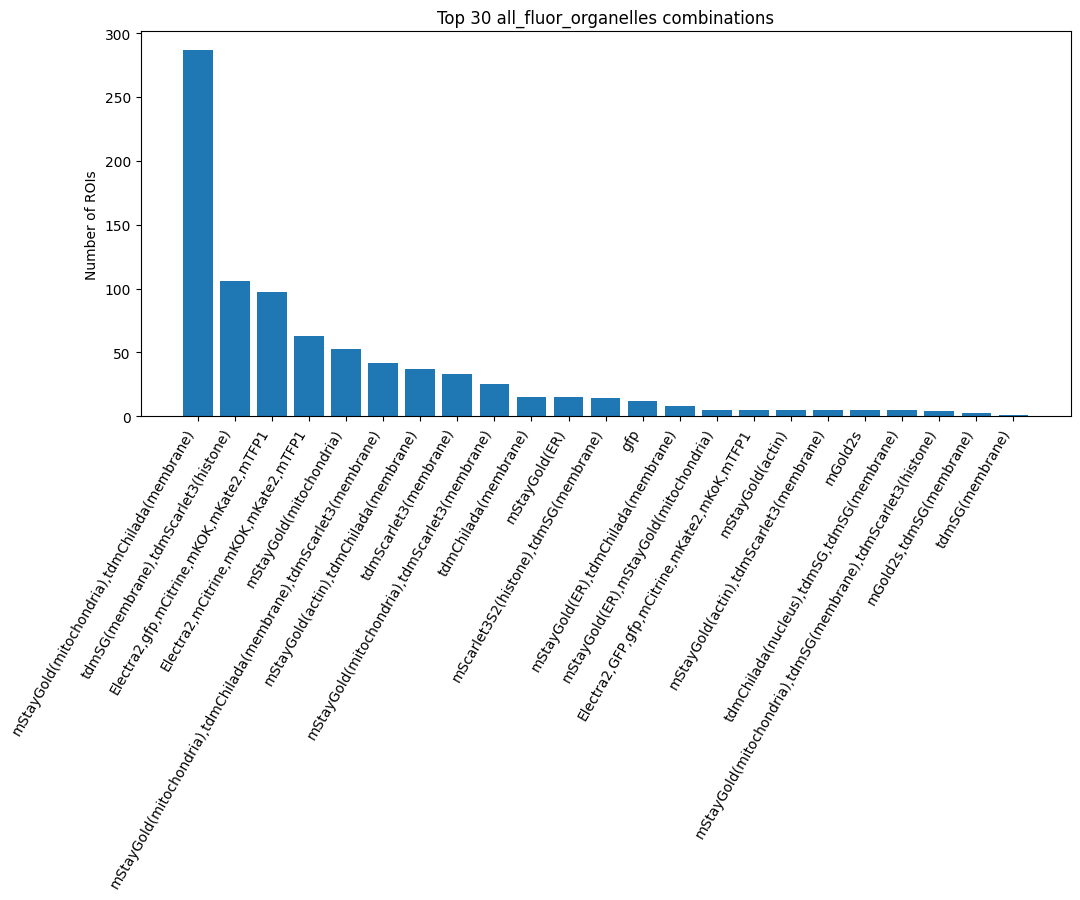

In [197]:
# CELL QA6: Plot counts of all_fluor_organelles combinations

import matplotlib.pyplot as plt
import pandas as pd
import math

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

# get value counts for the fluor-organelle combos, ignore blanks
fluor_combo_counts = (
    df.loc[~df["all_fluor_organelles"].apply(is_blank), "all_fluor_organelles"]
      .value_counts()
)

print("Unique fluor(organelle) combinations (top 50):")
display(fluor_combo_counts.head(50))

# Plot top N fluor-organelle combos as-is
topN = 30
top = fluor_combo_counts.head(topN)

plt.figure(figsize=(12, 5))
plt.bar(top.index, top.values)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Number of ROIs")
plt.title(f"Top {topN} all_fluor_organelles combinations")
plt.tight_layout()
plt.show()

In [198]:
# CELL 11 (FIXED): conservative propagation within date_experiment
# Only fill *safe* metadata when every non-blank value in a date_experiment agrees.
# We do NOT propagate any fusion / fluor / organelle rollups here.

import math

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

# Columns we are allowed to propagate IF they are unique per date_experiment.
# These should be true mount/experiment-level metadata, not per-ROI features.
SAFE_PROP_COLS = [
    "parent_female",
    "parent_male",
    "genotype_base_codes",
    "genotype_allele_codes",
    "treatment_plasmid_base_codes",
    "treatment_rna_base_codes",
    "manual_injection_plasmid_base_codes",   # only if you created this column
]

# Build canonical values per date_experiment, but only when unique
canonical_by_slug: dict[str, dict[str, str]] = {}

for slug, sub in df.groupby("date_experiment", dropna=False):
    can: dict[str, str] = {}
    for col in SAFE_PROP_COLS:
        if col not in sub.columns:
            continue
        series = sub[col]
        # non-blank, stringified, stripped
        vals = [str(v).strip() for v in series if not is_blank(v)]
        uniq = sorted(set(vals))
        if len(uniq) == 1:
            # only propagate if every non-blank value agrees
            can[col] = uniq[0]
    if can:
        canonical_by_slug[slug] = can

print("[E11] slugs with at least one safely-propagated column:", len(canonical_by_slug))

# Apply propagation
prop_counts = {c: 0 for c in SAFE_PROP_COLS}

for idx, row in df.iterrows():
    slug = row.get("date_experiment")
    if slug not in canonical_by_slug:
        continue
    can = canonical_by_slug[slug]
    for col, val in can.items():
        if col not in df.columns:
            continue
        if is_blank(row.get(col)):
            df.at[idx, col] = val
            prop_counts[col] += 1

print("[E11] propagation counts (only safe, unique-per-date_experiment):")
for col, n in prop_counts.items():
    if n:
        print(f"  {col}: filled {n} rows")

[E11] slugs with at least one safely-propagated column: 83
[E11] propagation counts (only safe, unique-per-date_experiment):
  parent_female: filled 53 rows
  parent_male: filled 53 rows
  genotype_base_codes: filled 4 rows
  genotype_allele_codes: filled 4 rows
  treatment_plasmid_base_codes: filled 85 rows
  treatment_rna_base_codes: filled 4 rows


Unique fluor(organelle) combinations (top 50):


all_fluor_organelles
mStayGold(mitochondria),tdmChilada(membrane)                          287
tdmSG(membrane),tdmScarlet3(histone)                                  106
Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1                                97
Electra2,mCitrine,mKOK,mKate2,mTFP1                                    63
mStayGold(mitochondria)                                                53
mStayGold(mitochondria),tdmChilada(membrane),tdmScarlet3(membrane)     42
mStayGold(actin),tdmChilada(membrane)                                  37
tdmScarlet3(membrane)                                                  33
mStayGold(mitochondria),tdmScarlet3(membrane)                          25
tdmChilada(membrane)                                                   15
mStayGold(ER)                                                          15
mScarlet3S2(histone),tdmSG(membrane)                                   14
gfp                                                                    12
mStayGold(ER),tdm

/var/folders/29/cdrb2nrn01s4d1_n6gvxy5j80000gn/T/ipykernel_392/3478889648.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


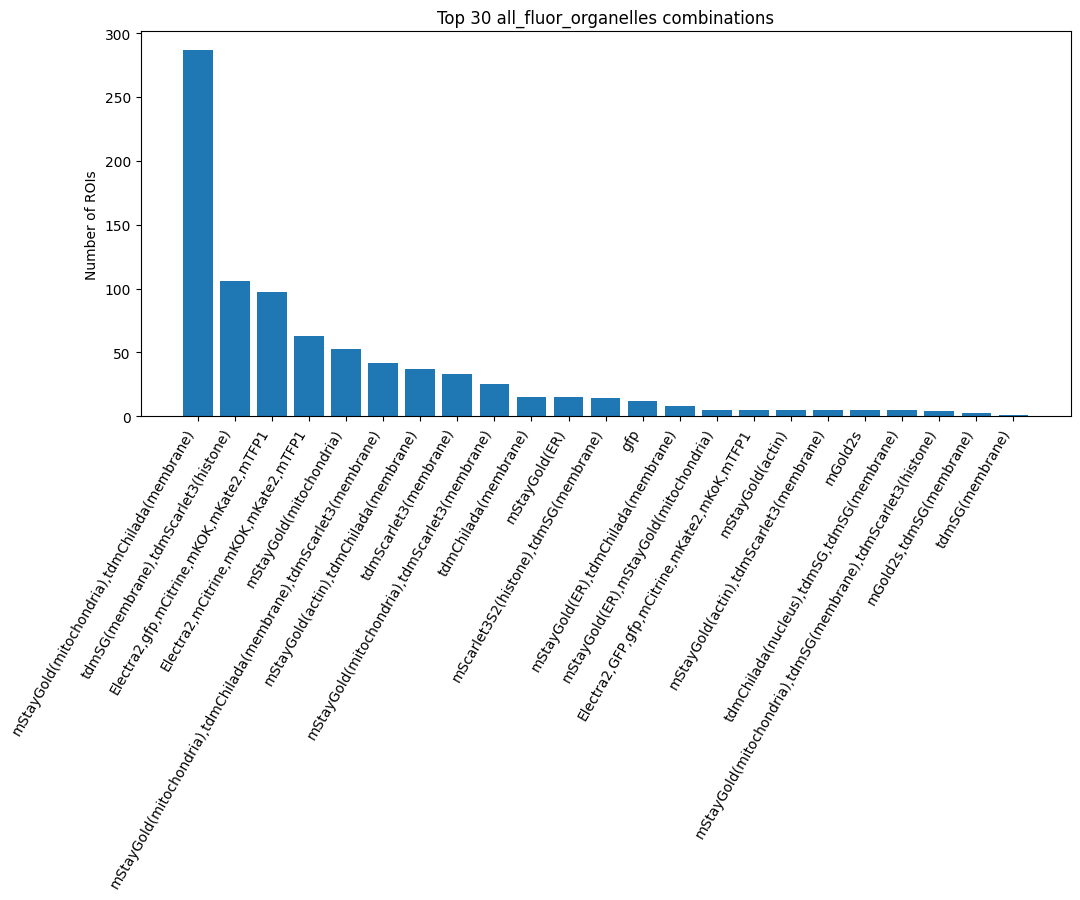

In [199]:
# CELL QA6: Plot counts of all_fluor_organelles combinations

import matplotlib.pyplot as plt
import pandas as pd
import math

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

# get value counts for the fluor-organelle combos, ignore blanks
fluor_combo_counts = (
    df.loc[~df["all_fluor_organelles"].apply(is_blank), "all_fluor_organelles"]
      .value_counts()
)

print("Unique fluor(organelle) combinations (top 50):")
display(fluor_combo_counts.head(50))

# Plot top N fluor-organelle combos as-is
topN = 30
top = fluor_combo_counts.head(topN)

plt.figure(figsize=(12, 5))
plt.bar(top.index, top.values)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Number of ROIs")
plt.title(f"Top {topN} all_fluor_organelles combinations")
plt.tight_layout()
plt.show()

In [200]:
# CELL 12: Add summary count columns (n_fusions, n_tags, n_unique_organelles)

import math
import re

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

def count_items(val: object) -> int:
    """Count comma/semicolon-separated non-empty items."""
    if is_blank(val):
        return 0
    s = str(val).replace(";", ",")
    return sum(1 for t in s.split(",") if t.strip())

# fusions
df["n_genotype_fusions"]  = df["genotype_marker_fusion_labels"].apply(count_items)
df["n_treatment_fusions"] = df["treatment_marker_fusion_labels"].apply(count_items)
df["n_total_fusions"]     = df["n_genotype_fusions"] + df["n_treatment_fusions"]

# tags
df["n_genotype_tags"]  = df["genotype_marker_tag_codes"].apply(count_items) if "genotype_marker_tag_codes" in df.columns else 0
df["n_treatment_tags"] = df["treatment_marker_tag_codes"].apply(count_items) if "treatment_marker_tag_codes" in df.columns else 0
df["n_total_tags"]     = df["n_genotype_tags"] + df["n_treatment_tags"]

# unique organelles
df["n_unique_organelles"] = df["all_unique_organelles"].apply(count_items)

# quick sanity check
df[[
    "roi_dir",
    "date_experiment",
    "genotype_marker_fusion_labels",
    "treatment_marker_fusion_labels",
    "all_unique_organelles",
    "n_genotype_fusions",
    "n_treatment_fusions",
    "n_total_fusions",
    "n_genotype_tags",
    "n_treatment_tags",
    "n_total_tags",
    "n_unique_organelles",
]].head(25)

,roi_dir,date_experiment,genotype_marker_fusion_labels,treatment_marker_fusion_labels,all_unique_organelles,n_genotype_fusions,n_treatment_fusions,n_total_fusions,n_genotype_tags,n_treatment_tags,n_total_tags,n_unique_organelles
0,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250428_mem_histone,tdmSG::2xLynk(N),mScarlet3S2::H2B(N),"histone,membrane",1,1,2,1,1,2,2
1,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250428_mem_histone,tdmSG::2xLynk(N),mScarlet3S2::H2B(N),"histone,membrane",1,1,2,1,1,2,2
2,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,tdmSG::2xLynk(N),mGold2s,membrane,1,1,2,1,0,1,1
3,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,tdmSG::2xLynk(N),mGold2s,membrane,1,1,2,1,0,1,1
4,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,tdmSG::2xLynk(N),mGold2s,membrane,1,1,2,1,0,1,1
5,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,None,mGold2s,None,0,1,1,0,0,0,0
6,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,None,mGold2s,None,0,1,1,0,0,0,0
7,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,None,mGold2s,None,0,1,1,0,0,0,0
8,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,None,mGold2s,None,0,1,1,0,0,0,0
9,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,None,mGold2s,None,0,1,1,0,0,0,0


In [201]:
# CELL 13: Patch Halo as a fluor for mem-halo lines

import math

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

def has_halo(row):
    """Detect mem-halo lines from parents or experiment slug."""
    texts = [
        row.get("parent_female") or "",
        row.get("parent_male") or "",
        row.get("date_experiment") or "",
    ]
    s = " ".join(str(t) for t in texts).lower()
    # look for 'halo' AND some hint of membrane (mem or membrane)
    return ("halo" in s) and ("mem" in s or "membrane" in s)

mask_halo = df.apply(has_halo, axis=1)

for idx, row in df[mask_halo].iterrows():
    # existing genotype markers
    fusions = split_codes(row.get("genotype_marker_fusion_labels"))
    locs   = split_codes(row.get("genotype_marker_localizations"))
    fluor_loc = split_codes(row.get("genotype_marker_fluor_loc_labels"))
    fusion_loc = split_codes(row.get("genotype_marker_fusion_loc_labels"))

    # ensure Halo appears as a fusion
    if "Halo" not in fusions:
        fusions.append("Halo")
    # ensure membrane is in genotype localizations
    if "membrane" not in locs:
        locs.append("membrane")
    # ensure fluor_loc has Halo(membrane)
    if "Halo(membrane)" not in fluor_loc:
        fluor_loc.append("Halo(membrane)")
    # fusion_loc: no tag, so treat like fluor_loc
    if "Halo(membrane)" not in fusion_loc:
        fusion_loc.append("Halo(membrane)")

    # write back joined strings
    df.at[idx, "genotype_marker_fusion_labels"]     = ",".join(sorted(set(fusions))) if fusions else None
    df.at[idx, "genotype_marker_localizations"]     = ",".join(sorted(set(locs)))    if locs   else None
    df.at[idx, "genotype_marker_fluor_loc_labels"]  = ",".join(sorted(set(fluor_loc))) if fluor_loc else None
    df.at[idx, "genotype_marker_fusion_loc_labels"] = ",".join(sorted(set(fusion_loc))) if fusion_loc else None

# sanity check on a few halo rows
df.loc[mask_halo, [
    "roi_dir",
    "date_experiment",
    "parent_female",
    "parent_male",
    "genotype_marker_fusion_labels",
    "genotype_marker_localizations",
    "genotype_marker_fluor_loc_labels",
    "genotype_marker_fusion_loc_labels",
]].head(20)

,roi_dir,date_experiment,parent_female,parent_male,genotype_marker_fusion_labels,genotype_marker_localizations,genotype_marker_fluor_loc_labels,genotype_marker_fusion_loc_labels
5,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,Halo,membrane,Halo(membrane),Halo(membrane)
6,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,Halo,membrane,Halo(membrane),Halo(membrane)
7,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,Halo,membrane,Halo(membrane),Halo(membrane)
8,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,Halo,membrane,Halo(membrane),Halo(membrane)
9,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,Halo,membrane,Halo(membrane),Halo(membrane)
332,/clusterfs/vast/abcabc/Korra_Foundation/202507...,20250723_mem-halo_ER-mSG,membrane Halo,membrane Halo,Halo,membrane,Halo(membrane),Halo(membrane)
333,/clusterfs/vast/abcabc/Korra_Foundation/202507...,20250723_mem-halo_ER-mSG,membrane Halo,membrane Halo,Halo,membrane,Halo(membrane),Halo(membrane)
334,/clusterfs/vast/abcabc/Korra_Foundation/202507...,20250723_mem-halo_ER-mSG,membrane Halo,membrane Halo,Halo,membrane,Halo(membrane),Halo(membrane)
335,/clusterfs/vast/abcabc/Korra_Foundation/202507...,20250723_mem-halo_ER-mSG,membrane Halo,membrane Halo,Halo,membrane,Halo(membrane),Halo(membrane)
336,/clusterfs/vast/abcabc/Korra_Foundation/202507...,20250723_mem-halo_ER-mSG,membrane Halo,membrane Halo,Halo,membrane,Halo(membrane),Halo(membrane)


In [202]:
# CELL E14 — Infer fusions & organelles from folder name for rows with remaining holes

import re

# ----------------------------------------------------------
# 1. Identify rows with *true* holes
# ----------------------------------------------------------
hole_mask = (
    df["genotype_marker_fusion_labels"].isna() &
    df["treatment_marker_fusion_labels"].isna() &
    df["all_unique_organelles"].isna()
)

df_missing = df[hole_mask].copy()
print(f"[E14] Rows with remaining holes: {df_missing.shape[0]}")


# ----------------------------------------------------------
# 2. Folder-based organelle dictionary
# ----------------------------------------------------------
ORG_PATTERNS = {
    r"(mem_|mem\-|membr|mem$)":      ("membrane",    "Halo"),     # defaults to Halo if no fluor
    r"(mito|cox8a)":                 ("mitochondria","mStayGold"),
    r"(er[\-_]|_er|sec61|calnexin)": ("ER",          "mStayGold"),
    r"(lam|lamellipodia)":           ("Lamellipodia","mStayGold"),
    r"(peroxi|pex)":                 ("peroxisome",  "mStayGold"),
    r"(cyto|cytosol)":               ("cytosol",     "mScarlet3S2"),
    r"(nuc|histone|h2b)":            ("nuclei",      "tdmSG"),
    r"(lys|lyso)":                   ("lysosome",    "mScarlet3S2"),
    r"(golgi)":                      ("golgi",       "mScarlet3S2"),
    r"(actin|lifeact)":              ("actin",       "mStayGold"),
}


# ----------------------------------------------------------
# 3. Helper to infer from folder name
# ----------------------------------------------------------
def infer_from_folder(path: str):
    p = path.lower()
    found = []
    for pattern, (org, default_fluor) in ORG_PATTERNS.items():
        if re.search(pattern, p):
            found.append((org, default_fluor))
    return found


# ----------------------------------------------------------
# 4. Apply inference and fill missing fields
# ----------------------------------------------------------
for idx, row in df_missing.iterrows():
    inferred = infer_from_folder(row["roi_dir"])
    if not inferred:
        continue

    # separate organelles + default fluors
    organs = [o for o, f in inferred]
    fluors = [f"{f}({o})" for o, f in inferred]   # e.g., mStayGold(mitochondria)
    fusion_labels = [f for f, o in zip([f.split("(")[0] for f in fluors], organs)]

    df.at[idx, "all_unique_organelles"] = ",".join(sorted(set(organs)))
    df.at[idx, "all_fluor_organelles"] = ",".join(sorted(fluors))

    # fill genotype if empty
    if pd.isna(row["genotype_marker_fusion_labels"]):
        df.at[idx, "genotype_marker_fusion_labels"] = ",".join(sorted(fusion_labels))
        df.at[idx, "genotype_marker_localizations"] = ",".join(sorted(set(organs)))
        df.at[idx, "genotype_marker_fluor_loc_labels"] = ",".join(sorted(fluors))
        df.at[idx, "genotype_marker_fusion_loc_labels"] = ",".join(sorted(fluors))

    # fallback note
    df.at[idx, "fusion_labels_inferred_from_folder"] = True

print("[E14] Folder-name inference applied.")

[E14] Rows with remaining holes: 232
[E14] Folder-name inference applied.


In [203]:
# Which rows are still "holes" after E14?
hole_mask = (
    df["genotype_marker_fusion_labels"].isna() &
    df["treatment_marker_fusion_labels"].isna() &
    df["all_unique_organelles"].isna()
)

df_holes = df.loc[hole_mask].copy()
print("Remaining holes:", df_holes.shape[0])

# Are they skittle-based?
df_holes_skittle = df_holes[
    df_holes["date_experiment"].astype(str).str.contains("skittle", case=False)
    | df_holes["roi_dir"].astype(str).str.contains("skittle", case=False)
]

print("Holes with 'skittle' in slug or roi_dir:", df_holes_skittle.shape[0])

# Quick breakdown by date_experiment
holes_by_slug = (
    df_holes["date_experiment"].value_counts()
    .rename_axis("date_experiment")
    .reset_index(name="n_rows")
)
holes_by_slug.head(30)

Remaining holes: 88
Holes with 'skittle' in slug or roi_dir: 87


,date_experiment,n_rows
0,20250513_skittles,43
1,20250522_skittlez,19
2,20250627_skittlez,12
3,20250625_skittlez,10
4,20250528_skittlez,2
5,20251009_skittlez,1
6,20251017_microtubules,1


In [204]:
# CELL 15 FINAL_ORGS: Rebuild canonical localizations + rollups AFTER all patches

import math
import re

# -------- basic helpers --------

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

def split_locs(val: object) -> list[str]:
    """Split comma/semicolon-separated locations into a clean list."""
    if is_blank(val):
        return []
    s = str(val).replace(";", ",")
    return [p.strip() for p in s.split(",") if p.strip()]

# -------- canonical organelle map (same as before) --------

canonical_organelle_map = {
    "membrane": "membrane",
    "mem": "membrane",
    "plasma_membrane": "membrane",

    "nucleus": "nucleus",
    "nuclei": "nucleus",

    "mito": "mitochondria",
    "mitochondria": "mitochondria",

    "er": "ER",
    "endoplasmic_reticulum": "ER",

    "golgi": "golgi",

    "peroxi": "peroxisome",
    "peroxisome": "peroxisome",

    "lam": "lamellipodia",
    "lamellipodia": "lamellipodia",

    "actin": "actin",
    "f-actin": "actin",

    "histone": "histone",
    "chromatin": "histone",
}

def canonicalize_organelle(label: str) -> str:
    if not isinstance(label, str) or not label.strip():
        return ""
    low = label.strip().lower()
    if low in canonical_organelle_map:
        return canonical_organelle_map[low]
    for k, v in canonical_organelle_map.items():
        if k in low:
            return v
    return label.strip()

def combine_unique_lists(*args) -> list[str]:
    seen = set()
    out  = []
    for lst in args:
        for x in lst:
            if not x:
                continue
            if x not in seen:
                seen.add(x)
                out.append(x)
    return out

# -------- recompute *_localizations_norm from final *_localizations --------

df["genotype_marker_localizations_norm"] = (
    df.get("genotype_marker_localizations", pd.Series([None]*len(df)))
      .apply(lambda x: [canonicalize_organelle(t) for t in split_locs(x)])
)

df["treatment_marker_localizations_norm"] = (
    df.get("treatment_marker_localizations", pd.Series([None]*len(df)))
      .apply(lambda x: [canonicalize_organelle(t) for t in split_locs(x)])
)

# -------- rebuild all_unique_organelles --------

def row_all_organelles(row: pd.Series) -> str | None:
    g = row.get("genotype_marker_localizations_norm", []) or []
    t = row.get("treatment_marker_localizations_norm", []) or []
    combined = combine_unique_lists(g, t)
    combined = sorted(set(x for x in combined if x))
    return ",".join(combined) if combined else None

df["all_unique_organelles"] = df.apply(row_all_organelles, axis=1)

# -------- rebuild all_fluor_organelles from fluor_loc labels --------

def parse_fluor_loc_labels(val: object) -> list[str]:
    toks = split_locs(val)
    out = []
    for tok in toks:
        m = re.match(r"^(.*?)\((.*?)\)$", tok)
        if m:
            fluor = m.group(1).strip()
            org   = canonicalize_organelle(m.group(2).strip())
            out.append(f"{fluor}({org})")
        else:
            out.append(tok.strip())
    return out

def row_all_fluor_organelles(row: pd.Series) -> str | None:
    g = parse_fluor_loc_labels(row.get("genotype_marker_fluor_loc_labels"))
    t = parse_fluor_loc_labels(row.get("treatment_marker_fluor_loc_labels"))
    combined = combine_unique_lists(g, t)
    combined = sorted(set(x for x in combined if x))
    return ",".join(combined) if combined else None

df["all_fluor_organelles"] = df.apply(row_all_fluor_organelles, axis=1)

# -------- sanity checks on the exact rows you flagged --------

print("\n[FINAL_ORGS] mem-halo ER–mSG, test rows:")
mask_mem_halo = df["roi_dir"].astype(str).str.contains("20250723_mem-halo_ER-mSG", case=False)
display(
    df.loc[mask_mem_halo, [
        "roi_dir",
        "genotype_marker_fusion_labels",
        "genotype_marker_localizations",
        "treatment_marker_fusion_labels",
        "treatment_marker_localizations",
        "all_unique_organelles",
        "all_fluor_organelles",
    ]].head(10)
)

print("\n[FINAL_ORGS] 20251013_mem-histone, test rows:")
mask_mem_hist = df["roi_dir"].astype(str).str.contains("20251013_mem-histone", case=False)
display(
    df.loc[mask_mem_hist, [
        "roi_dir",
        "genotype_marker_fusion_labels",
        "genotype_marker_localizations",
        "treatment_marker_fusion_labels",
        "treatment_marker_localizations",
        "all_unique_organelles",
        "all_fluor_organelles",
    ]].head(10)
)


[FINAL_ORGS] mem-halo ER–mSG, test rows:


,roi_dir,genotype_marker_fusion_labels,genotype_marker_localizations,treatment_marker_fusion_labels,treatment_marker_localizations,all_unique_organelles,all_fluor_organelles
332,/clusterfs/vast/abcabc/Korra_Foundation/202507...,Halo,membrane,mStayGold::sec61b(N),ER,"ER,membrane","Halo(membrane),mStayGold(ER)"
333,/clusterfs/vast/abcabc/Korra_Foundation/202507...,Halo,membrane,mStayGold::sec61b(N),ER,"ER,membrane","Halo(membrane),mStayGold(ER)"
334,/clusterfs/vast/abcabc/Korra_Foundation/202507...,Halo,membrane,mStayGold::sec61b(N),ER,"ER,membrane","Halo(membrane),mStayGold(ER)"
335,/clusterfs/vast/abcabc/Korra_Foundation/202507...,Halo,membrane,mStayGold::sec61b(N),ER,"ER,membrane","Halo(membrane),mStayGold(ER)"
336,/clusterfs/vast/abcabc/Korra_Foundation/202507...,Halo,membrane,mStayGold::sec61b(N),ER,"ER,membrane","Halo(membrane),mStayGold(ER)"
337,/clusterfs/vast/abcabc/Korra_Foundation/202507...,Halo,membrane,mStayGold::sec61b(N),ER,"ER,membrane","Halo(membrane),mStayGold(ER)"



[FINAL_ORGS] 20251013_mem-histone, test rows:


,roi_dir,genotype_marker_fusion_labels,genotype_marker_localizations,treatment_marker_fusion_labels,treatment_marker_localizations,all_unique_organelles,all_fluor_organelles
357,/clusterfs/vast/abcabc/Korra_Foundation/202510...,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane",None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
358,/clusterfs/vast/abcabc/Korra_Foundation/202510...,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane",None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
359,/clusterfs/vast/abcabc/Korra_Foundation/202510...,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane",None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
360,/clusterfs/vast/abcabc/Korra_Foundation/202510...,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane",None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
361,/clusterfs/vast/abcabc/Korra_Foundation/202510...,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane",None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
362,/clusterfs/vast/abcabc/Korra_Foundation/202510...,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane",None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
363,/clusterfs/vast/abcabc/Korra_Foundation/202510...,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane",None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
364,/clusterfs/vast/abcabc/Korra_Foundation/202510...,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane",None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
365,/clusterfs/vast/abcabc/Korra_Foundation/202510...,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane",None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"
949,/clusterfs/vast/abcabc/Aang_Foundation/2025101...,"tdmSG::2xLynk(N),tdmScarlet3::H2B(C)","histone,membrane",None,None,"histone,membrane","tdmSG(membrane),tdmScarlet3(histone)"


In [205]:
# CELL 9: Write full enriched master sheet (v2)

from pathlib import Path

BASE    = Path("/Users/davekokel/Projects/carp_v2")
WORKING = BASE / "seed_kits" / "legacy_wrangling" / "working"

v2_full_path = WORKING / "legacy_imaging_annotations_v2.csv"
df.to_csv(v2_full_path, index=False)

v2_full_path, df.shape, df.columns.tolist()

(PosixPath('/Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling/working/legacy_imaging_annotations_v2.csv'),
 (1077, 65),
 ['date_experiment',
  'fish',
  'roi_rel',
  'roi_name',
  'roi_tiffs',
  'roi_dir',
  'dataset',
  'mount_dir_norm',
  'date_mount',
  'mount_id',
  'ZF female genotype',
  'ZF male genotype',
  'additional plasmids injected',
  'additional mRNAs injected',
  'additonal proteins injected',
  'additonal dye and chemicals',
  'Date born',
  'Time mounted',
  'Mounting Orientation',
  'Date screened/Initial feedback',
  'Date imaged',
  'Time placed in scope',
  'Start of imaging time',
  'End of imaging time',
  'Imaged Locations',
  'Unique Targets with blanks',
  'Unique Targets',
  'Data location',
  'parent_female',
  'parent_male',
  'roi_dir_norm',
  'mother_fish_manual',
  'father_fish_manual',
  'injection plasmid',
  'manual_injection_plasmid_codes',
  'genotype_base_codes',
  'genotype_allele_codes',
  'treatment_plasmid_base_codes',
  'treatment_

In [206]:
# CELL 10: Build a slim DB upload view from v2

from pathlib import Path

BASE    = Path("/Users/davekokel/Projects/carp_v2")
WORKING = BASE / "seed_kits" / "legacy_wrangling" / "working"

# Columns we want in the DB-facing ROI table.
# (Only the ones that are truly per-ROI or stable metadata.)
upload_cols = [
    # structural / IDs
    "roi_dir",
    "mount_dir_norm",
    "date_experiment",
    "date_mount",
    "fish",
    "roi_name",
    "roi_rel",

    # parents
    "parent_female",
    "parent_male",

    # genotype summary
    "genotype_base_codes",
    "genotype_allele_codes",
    "genotype_marker_fusion_labels",
    "genotype_marker_localizations",
    "genotype_marker_fluor_loc_labels",
    "genotype_marker_fusion_loc_labels",

    # treatment summary
    "treatment_plasmid_base_codes",
    "treatment_rna_base_codes",
    "treatment_marker_fusion_labels",
    "treatment_marker_localizations",
    "treatment_marker_fluor_loc_labels",
    "treatment_marker_fusion_loc_labels",

    # rollups
    "all_marker_fluor_codes",
    "all_unique_organelles",
    "all_fluor_organelles",
]

# In case some columns don't exist yet, filter to ones that do.
upload_cols = [c for c in upload_cols if c in df.columns]

df_upload = df[upload_cols].copy()

v2_upload_path = WORKING / "legacy_imaging_annotations_for_db_v2.csv"
df_upload.to_csv(v2_upload_path, index=False)

v2_upload_path, df_upload.shape

(PosixPath('/Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling/working/legacy_imaging_annotations_for_db_v2.csv'),
 (1077, 23))

In [207]:
# CELL QA1: Summary by genotype_base_codes

summary_geno = (
    df.groupby("genotype_base_codes", dropna=False)
      .agg(
          n_rois=("roi_dir", "count"),
          n_experiments=("date_experiment", "nunique"),
          avg_unique_organelles=("n_unique_organelles", "mean"),
      )
      .sort_values("n_rois", ascending=False)
)

summary_geno.head(30)

,n_rois,n_experiments,avg_unique_organelles
genotype_base_codes,,,
NaN,234,25,0.055556
pDQM082,195,9,2.000000
"nan,pDQM082",173,15,1.913295
"pDQM005,pDQM133",110,11,2.036364
"pDQM034,pDQM059",80,4,0.000000
Swinburne,50,6,0.900000
pDQM136,43,3,1.488372
"nan,pDQM136",41,7,1.731707
pDQM034,40,2,0.000000


In [208]:
# CELL QA2: Summary by treatment plasmid and RNA base codes

summary_treat = (
    df.groupby(["treatment_plasmid_base_codes", "treatment_rna_base_codes"], dropna=False)
      .agg(
          n_rois=("roi_dir", "count"),
          n_experiments=("date_experiment", "nunique"),
          avg_unique_organelles=("n_unique_organelles", "mean"),
      )
      .sort_values("n_rois", ascending=False)
)

summary_treat.head(30)

n_rois  n_experiments  \
treatment_plasmid_base_codes treatment_rna_base_codes                          
NaN                          NaN                          471             47   
                             MGCO-01                      408             23   
pDQM034,pDQM036              NaN                           44              1   
MGCO-01                      NaN                           32              3   
NaN                          MGCO-23                       32              4   
                             MGCO-04                       23              3   
                             pDQM117                       18              5   
                             HC-9                          15              3   
MGCO-49                      NaN                           10              1   
pDQM140                      NaN                            8              1   
MGCO-04,MGCO-01              NaN                            6              2   
NaN                          pDQM037                        5              2   
MGCO-01,MGCO-04              NaN                            4              1   
MGCO-57                      NaN                            1              1   

                                                       avg_unique_organelles  
treatment_plasmid_base_codes treatment_rna_base_codes                         
NaN                          NaN                                    0.554140  
                             MGCO-01                                1.887255  
pDQM034,pDQM036              NaN                                    0.000000  
MGCO-01                      NaN                                    0.093750  
NaN                          MGCO-23                                1.843750  
                             MGCO-04                                1.347826  
                             pDQM117                                1.555556  
                             HC-9                                   2.000000  
MGCO-49                      NaN                                    0.000000  
pDQM140                      NaN                                    0.375000  
MGCO-04,MGCO-01              NaN                                    1.333333  
NaN                          pDQM037                                2.000000  
MGCO-01,MGCO-04              NaN                                    0.500000  
MGCO-57                      NaN                                    0.000000

In [209]:
# CELL QA3: Summary by experiment + genotype + treatment

summary_slug = (
    df.groupby(["date_experiment", "genotype_base_codes", "treatment_plasmid_base_codes"], dropna=False)
      .agg(
          n_rois=("roi_dir", "count"),
          unique_orgs=("all_unique_organelles", lambda x: sorted(set(v for v in x if isinstance(v, str)))),
      )
      .reset_index()
      .sort_values("n_rois", ascending=False)
)

summary_slug.head(40)

,date_experiment,genotype_base_codes,treatment_plasmid_base_codes,n_rois,unique_orgs
42,20250819_mem_mito,"nan,pDQM082",NaN,50,"[membrane,mitochondria]"
3,20250513_skittles,NaN,"pDQM034,pDQM036",44,[]
50,20250908_mem-mito,pDQM082,NaN,44,"[membrane,mitochondria]"
43,20250821_mem_mito,"nan,pDQM082",NaN,30,"[membrane,mitochondria]"
93,20251106_mem-mito,pDQM082,NaN,26,"[membrane,mitochondria]"
52,20250912_mem-mito,pDQM082,NaN,26,"[membrane,mitochondria]"
56,20250918_mem-mito,pDQM082,NaN,26,"[membrane,mitochondria]"
63,20251002_mem_mito,NaN,MGCO-01,24,"[membrane,mitochondria, mitochondria]"
20,20250618_skittlez,pDQM034,NaN,23,[]
57,20250919_mem-mito,pDQM082,NaN,23,"[membrane,mitochondria]"


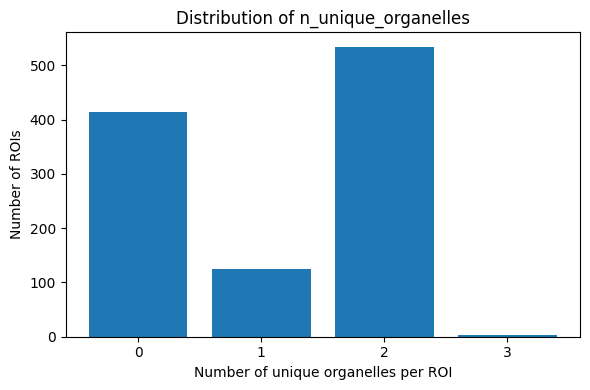

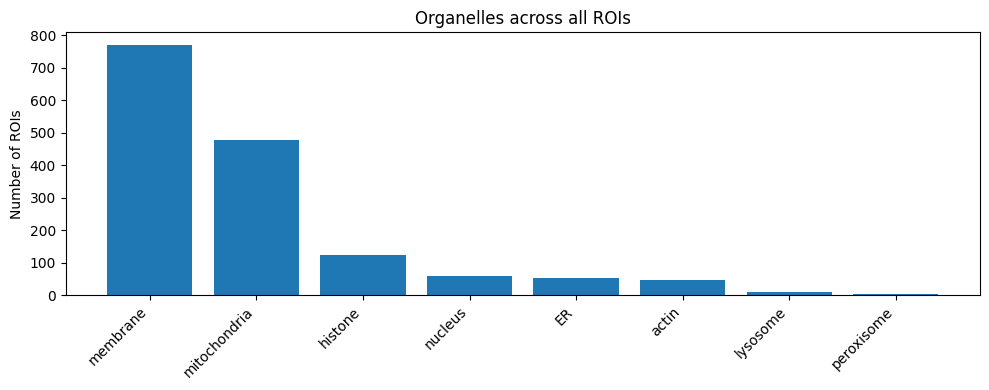

membrane        770
mitochondria    477
histone         124
nucleus          58
ER               52
actin            47
lysosome          9
peroxisome        4
dtype: int64

In [210]:
# CELL QA4: Plot n_unique_organelles and per-organelle counts

import matplotlib.pyplot as plt

# ---- distribution of n_unique_organelles ----
counts = df["n_unique_organelles"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Number of unique organelles per ROI")
plt.ylabel("Number of ROIs")
plt.title("Distribution of n_unique_organelles")
plt.tight_layout()
plt.show()

# ---- per-organelle frequency ----
from collections import Counter

org_counter = Counter()
for val in df["all_unique_organelles"].dropna():
    for o in str(val).replace(";", ",").split(","):
        o = o.strip()
        if o:
            org_counter[o] += 1

org_series = (
    pd.Series(org_counter)
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,4))
plt.bar(org_series.index, org_series.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of ROIs")
plt.title("Organelles across all ROIs")
plt.tight_layout()
plt.show()

org_series.head(30)

Unique organelle combinations (top 50):


all_unique_organelles
membrane,mitochondria            421
histone,membrane                 120
membrane                          69
membrane,nucleus                  56
actin,membrane                    47
mitochondria                      28
ER,membrane                       26
ER,membrane,mitochondria          19
lysosome,membrane                  8
ER,mitochondria                    5
histone,membrane,mitochondria      4
peroxisome                         4
ER                                 2
nucleus                            2
lysosome                           1
Name: count, dtype: int64

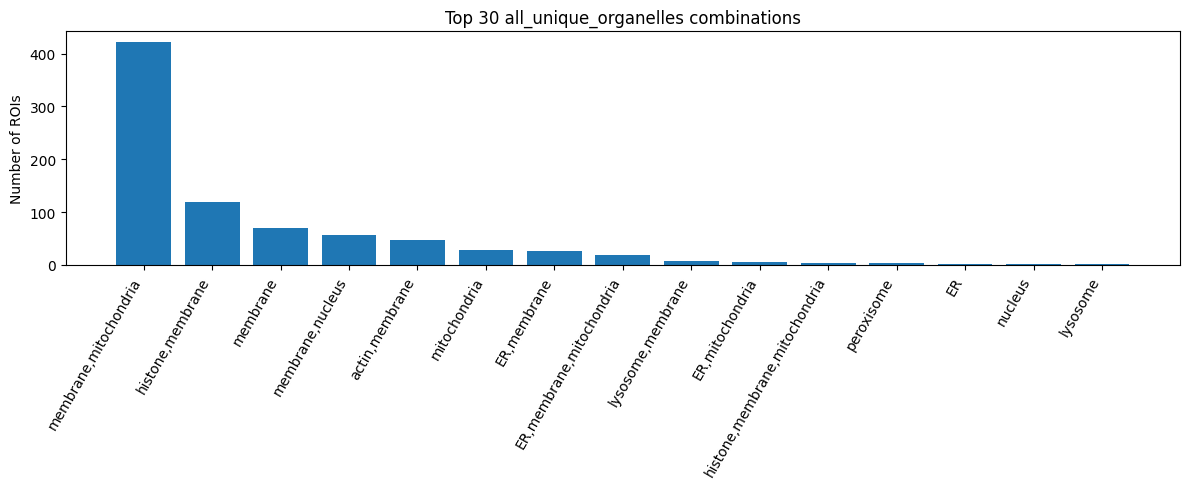

In [211]:
# CELL QA5: Plot counts of all_unique_organelles combinations

import matplotlib.pyplot as plt
import pandas as pd
import math

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

# get value counts for the combos, ignore blanks
combo_counts = (
    df.loc[~df["all_unique_organelles"].apply(is_blank), "all_unique_organelles"]
      .value_counts()
)

print("Unique organelle combinations (top 50):")
display(combo_counts.head(50))

# Plot top N combos
topN = 30
top = combo_counts.head(topN)

plt.figure(figsize=(12, 5))
plt.bar(top.index, top.values)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Number of ROIs")
plt.title(f"Top {topN} all_unique_organelles combinations")
plt.tight_layout()
plt.show()

Unique fluor(organelle) combinations (top 50):


all_fluor_organelles
mStayGold(mitochondria),tdmChilada(membrane)                          287
tdmSG(membrane),tdmScarlet3(histone)                                  106
Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1                                97
Halo(membrane),mStayGold(mitochondria)                                 67
Electra2,mCitrine,mKOK,mKate2,mTFP1                                    63
Halo(membrane),tdmSG(nucleus)                                          51
mStayGold(mitochondria),tdmChilada(membrane),tdmScarlet3(membrane)     42
mStayGold(actin),tdmChilada(membrane)                                  37
tdmScarlet3(membrane)                                                  33
mStayGold(mitochondria)                                                28
mStayGold(mitochondria),tdmScarlet3(membrane)                          25
Halo(membrane),mStayGold(ER),mStayGold(mitochondria)                   19
Halo(membrane),mStayGold(ER)                                           18
tdmChilada(membra

/var/folders/29/cdrb2nrn01s4d1_n6gvxy5j80000gn/T/ipykernel_392/3478889648.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


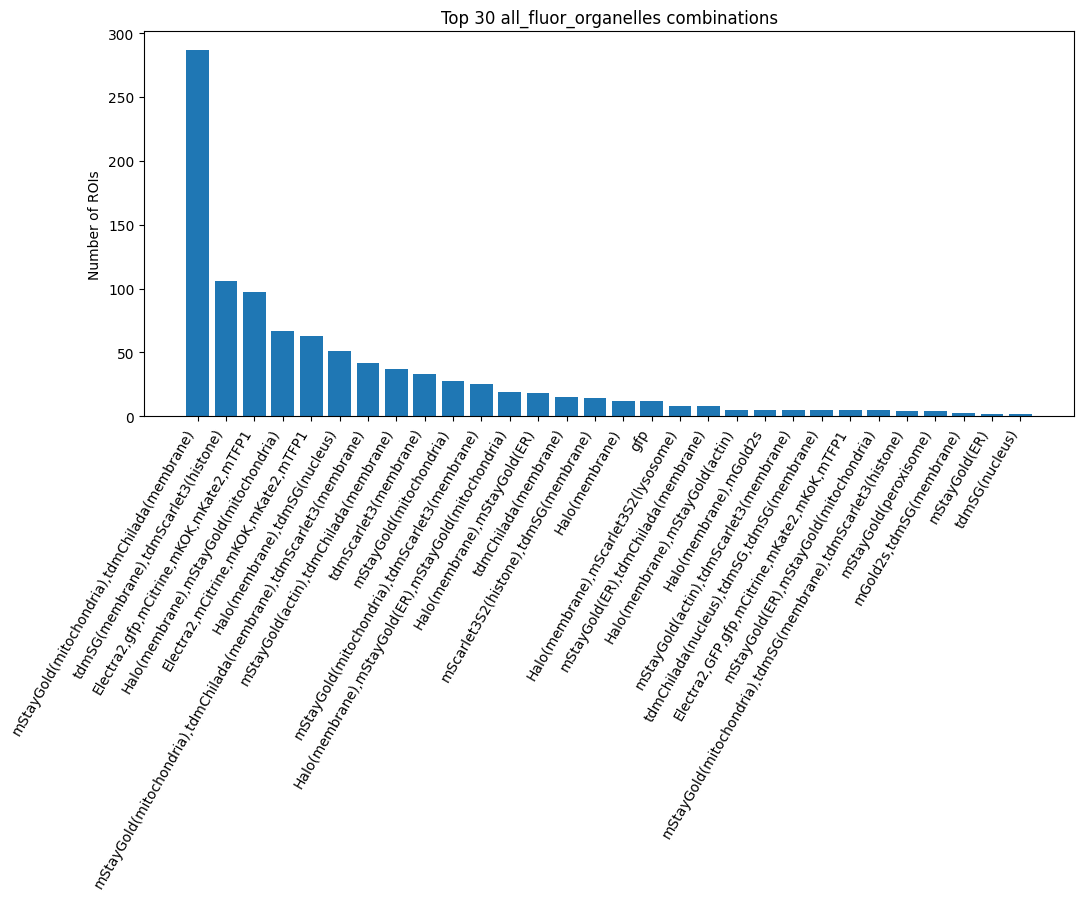

In [212]:
# CELL QA6: Plot counts of all_fluor_organelles combinations

import matplotlib.pyplot as plt
import pandas as pd
import math

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

# get value counts for the fluor-organelle combos, ignore blanks
fluor_combo_counts = (
    df.loc[~df["all_fluor_organelles"].apply(is_blank), "all_fluor_organelles"]
      .value_counts()
)

print("Unique fluor(organelle) combinations (top 50):")
display(fluor_combo_counts.head(50))

# Plot top N fluor-organelle combos as-is
topN = 30
top = fluor_combo_counts.head(topN)

plt.figure(figsize=(12, 5))
plt.bar(top.index, top.values)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Number of ROIs")
plt.title(f"Top {topN} all_fluor_organelles combinations")
plt.tight_layout()
plt.show()

In [177]:
show_roi("mem-halo check", roi_pattern="mem-halo")
show_roi("H2B check", roi_pattern="mem-histone")
show_roi("mem-mito check", roi_pattern="20251106_mem-mito")


===== mem-halo check — roi_pattern='mem-halo', fluor_combo=None, rows=32, cols_shown=19 =====


,roi_dir,date_experiment,parent_female,parent_male,genotype_base_codes,genotype_allele_codes,additional plasmids injected,additional mRNAs injected,manual_injection_plasmid_codes,treatment_plasmid_base_codes,treatment_rna_base_codes,genotype_marker_fusion_labels,genotype_marker_localizations,genotype_marker_fluor_loc_labels,treatment_marker_fusion_labels,treatment_marker_localizations,treatment_marker_fluor_loc_labels,all_unique_organelles,all_fluor_organelles
5,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,Swinburne,Swinburne:Swinburne,ef1a:mGold2s,NaN,None,pDQM140,None,Halo,membrane,Halo(membrane),mGold2s,None,mGold2s,membrane,"Halo(membrane),mGold2s"
6,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,Swinburne,Swinburne:Swinburne,ef1a:mGold2s,NaN,None,pDQM140,None,Halo,membrane,Halo(membrane),mGold2s,None,mGold2s,membrane,"Halo(membrane),mGold2s"
7,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,Swinburne,Swinburne:Swinburne,ef1a:mGold2s,NaN,None,pDQM140,None,Halo,membrane,Halo(membrane),mGold2s,None,mGold2s,membrane,"Halo(membrane),mGold2s"
8,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,Swinburne,Swinburne:Swinburne,ef1a:mGold2s,NaN,None,pDQM140,None,Halo,membrane,Halo(membrane),mGold2s,None,mGold2s,membrane,"Halo(membrane),mGold2s"
9,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,membrane Halo,membrane Halo,Swinburne,Swinburne:Swinburne,ef1a:mGold2s,NaN,None,pDQM140,None,Halo,membrane,Halo(membrane),mGold2s,None,mGold2s,membrane,"Halo(membrane),mGold2s"
332,/clusterfs/vast/abcabc/Korra_Foundation/202507...,20250723_mem-halo_ER-mSG,membrane Halo,membrane Halo,Swinburne,Swinburne:Swinburne,NaN,mSG:sec61b,None,None,MGCO-04,Halo,membrane,Halo(membrane),mStayGold::sec61b(N),ER,mStayGold(ER),"ER,membrane","Halo(membrane),mStayGold(ER)"
333,/clusterfs/vast/abcabc/Korra_Foundation/202507...,20250723_mem-halo_ER-mSG,membrane Halo,membrane Halo,Swinburne,Swinburne:Swinburne,NaN,mSG:sec61b,None,None,MGCO-04,Halo,membrane,Halo(membrane),mStayGold::sec61b(N),ER,mStayGold(ER),"ER,membrane","Halo(membrane),mStayGold(ER)"
334,/clusterfs/vast/abcabc/Korra_Foundation/202507...,20250723_mem-halo_ER-mSG,membrane Halo,membrane Halo,Swinburne,Swinburne:Swinburne,NaN,mSG:sec61b,None,None,MGCO-04,Halo,membrane,Halo(membrane),mStayGold::sec61b(N),ER,mStayGold(ER),"ER,membrane","Halo(membrane),mStayGold(ER)"
335,/clusterfs/vast/abcabc/Korra_Foundation/202507...,20250723_mem-halo_ER-mSG,membrane Halo,membrane Halo,Swinburne,Swinburne:Swinburne,NaN,mSG:sec61b,None,None,MGCO-04,Halo,membrane,Halo(membrane),mStayGold::sec61b(N),ER,mStayGold(ER),"ER,membrane","Halo(membrane),mStayGold(ER)"
336,/clusterfs/vast/abcabc/Korra_Foundation/202507...,20250723_mem-halo_ER-mSG,membrane Halo,membrane Halo,Swinburne,Swinburne:Swinburne,NaN,mSG:sec61b,None,None,MGCO-04,Halo,membrane,Halo(membrane),mStayGold::sec61b(N),ER,mStayGold(ER),"ER,membrane","Halo(membrane),mStayGold(ER)"



===== H2B check — roi_pattern='mem-histone', fluor_combo=None, rows=147, cols_shown=19 =====


,roi_dir,date_experiment,parent_female,parent_male,genotype_base_codes,genotype_allele_codes,additional plasmids injected,additional mRNAs injected,manual_injection_plasmid_codes,treatment_plasmid_base_codes,treatment_rna_base_codes,genotype_marker_fusion_labels,genotype_marker_localizations,genotype_marker_fluor_loc_labels,treatment_marker_fusion_labels,treatment_marker_localizations,treatment_marker_fluor_loc_labels,all_unique_organelles,all_fluor_organelles
88,/clusterfs/vast/abcabc/Korra_Foundation/202505...,20250528_mem-histone,ef1a:2xLynk:tdmSG(J) (F2 of allele 302),ef1a:2xLynk:tdmSG(J) (F2 of allele 302),pDQM005,pDQM005:302,NaN,mScarlet3-S2:H2B,None,None,pDQM117,tdmSG::2xLynk(N),membrane,tdmSG(membrane),mScarlet3S2::H2B(N),histone,mScarlet3S2(histone),"histone,membrane","mScarlet3S2(histone),tdmSG(membrane)"
89,/clusterfs/vast/abcabc/Korra_Foundation/202505...,20250528_mem-histone,ef1a:2xLynk:tdmSG(J) (F2 of allele 302),ef1a:2xLynk:tdmSG(J) (F2 of allele 302),pDQM005,pDQM005:302,NaN,mScarlet3-S2:H2B,None,None,pDQM117,tdmSG::2xLynk(N),membrane,tdmSG(membrane),mScarlet3S2::H2B(N),histone,mScarlet3S2(histone),"histone,membrane","mScarlet3S2(histone),tdmSG(membrane)"
90,/clusterfs/vast/abcabc/Korra_Foundation/202505...,20250528_mem-histone,ef1a:2xLynk:tdmSG(J) (F2 of allele 302),ef1a:2xLynk:tdmSG(J) (F2 of allele 302),pDQM005,pDQM005:302,NaN,mScarlet3-S2:H2B,None,None,pDQM117,tdmSG::2xLynk(N),membrane,tdmSG(membrane),mScarlet3S2::H2B(N),histone,mScarlet3S2(histone),"histone,membrane","mScarlet3S2(histone),tdmSG(membrane)"
115,/clusterfs/vast/abcabc/Korra_Foundation/202505...,20250530_mem-histone,ef1a:2xLynk:tdmSG(J) (F2 of allele 302),ef1a:2xLynk:tdmSG(J) (F2 of allele 302),pDQM005,pDQM005:302,NaN,mScarlet3-S2:H2B,None,None,pDQM117,tdmSG::2xLynk(N),membrane,tdmSG(membrane),mScarlet3S2::H2B(N),histone,mScarlet3S2(histone),"histone,membrane","mScarlet3S2(histone),tdmSG(membrane)"
116,/clusterfs/vast/abcabc/Korra_Foundation/202505...,20250530_mem-histone,ef1a:2xLynk:tdmSG(J) (F2 of allele 302),ef1a:2xLynk:tdmSG(J) (F2 of allele 302),pDQM005,pDQM005:302,NaN,mScarlet3-S2:H2B,None,None,pDQM117,tdmSG::2xLynk(N),membrane,tdmSG(membrane),mScarlet3S2::H2B(N),histone,mScarlet3S2(histone),"histone,membrane","mScarlet3S2(histone),tdmSG(membrane)"
117,/clusterfs/vast/abcabc/Korra_Foundation/202505...,20250530_mem-histone,ef1a:2xLynk:tdmSG(J) (F2 of allele 302),ef1a:2xLynk:tdmSG(J) (F2 of allele 302),pDQM005,pDQM005:302,NaN,mScarlet3-S2:H2B,None,None,pDQM117,tdmSG::2xLynk(N),membrane,tdmSG(membrane),mScarlet3S2::H2B(N),histone,mScarlet3S2(histone),"histone,membrane","mScarlet3S2(histone),tdmSG(membrane)"
181,/clusterfs/vast/abcabc/Korra_Foundation/202506...,20250609_mem-histone,None,None,None,None,NaN,NaN,None,None,None,"Halo,tdmSG","membrane,nuclei","Halo(membrane),tdmSG(nuclei)",None,None,None,"membrane,nucleus","Halo(membrane),tdmSG(nucleus)"
182,/clusterfs/vast/abcabc/Korra_Foundation/202506...,20250609_mem-histone,None,None,None,None,NaN,NaN,None,None,None,"Halo,tdmSG","membrane,nuclei","Halo(membrane),tdmSG(nuclei)",None,None,None,"membrane,nucleus","Halo(membrane),tdmSG(nucleus)"
183,/clusterfs/vast/abcabc/Korra_Foundation/202506...,20250609_mem-histone,None,None,None,None,NaN,NaN,None,None,None,"Halo,tdmSG","membrane,nuclei","Halo(membrane),tdmSG(nuclei)",None,None,None,"membrane,nucleus","Halo(membrane),tdmSG(nucleus)"
184,/clusterfs/vast/abcabc/Korra_Foundation/202506...,20250609_mem-histone,None,None,None,None,NaN,NaN,None,None,None,"Halo,tdmSG","membrane,nuclei","Halo(membrane),tdmSG(nuclei)",None,None,None,"membrane,nucleus","Halo(membrane),tdmSG(nucleus)"



===== mem-mito check — roi_pattern='20251106_mem-mito', fluor_combo=None, rows=26, cols_shown=19 =====


,roi_dir,date_experiment,parent_female,parent_male,genotype_base_codes,genotype_allele_codes,additional plasmids injected,additional mRNAs injected,manual_injection_plasmid_codes,treatment_plasmid_base_codes,treatment_rna_base_codes,genotype_marker_fusion_labels,genotype_marker_localizations,genotype_marker_fluor_loc_labels,treatment_marker_fusion_labels,treatment_marker_localizations,treatment_marker_fluor_loc_labels,all_unique_organelles,all_fluor_organelles
412,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
413,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
414,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
415,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
416,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
417,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
418,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
419,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
420,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(mitochondria),tdmChilada(membrane)"
421,/clusterfs/vast/abcabc/Korra_Foundation/202511...,20251106_mem-mito,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,NaN,2xCox8A:mSG,None,None,MGCO-01,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),"membrane,mitochondria","mStayGold(m

Unique fluor(organelle) combinations (top 50):


all_fluor_organelles
mStayGold(mitochondria),tdmChilada(membrane)                          287
tdmSG(membrane),tdmScarlet3                                           106
Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1                                97
Halo(membrane),mStayGold(mitochondria)                                 67
Electra2,mCitrine,mKOK,mKate2,mTFP1                                    63
Halo(membrane),tdmSG(nucleus)                                          51
mStayGold(mitochondria),tdmChilada(membrane),tdmScarlet3(membrane)     42
mStayGold(actin),tdmChilada(membrane)                                  37
tdmScarlet3(membrane)                                                  33
mStayGold(mitochondria)                                                28
mStayGold(mitochondria),tdmScarlet3(membrane)                          25
Halo(membrane),mStayGold(ER),mStayGold(mitochondria)                   19
Halo(membrane),mStayGold(ER)                                           18
tdmChilada(membra

/var/folders/29/cdrb2nrn01s4d1_n6gvxy5j80000gn/T/ipykernel_392/3478889648.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


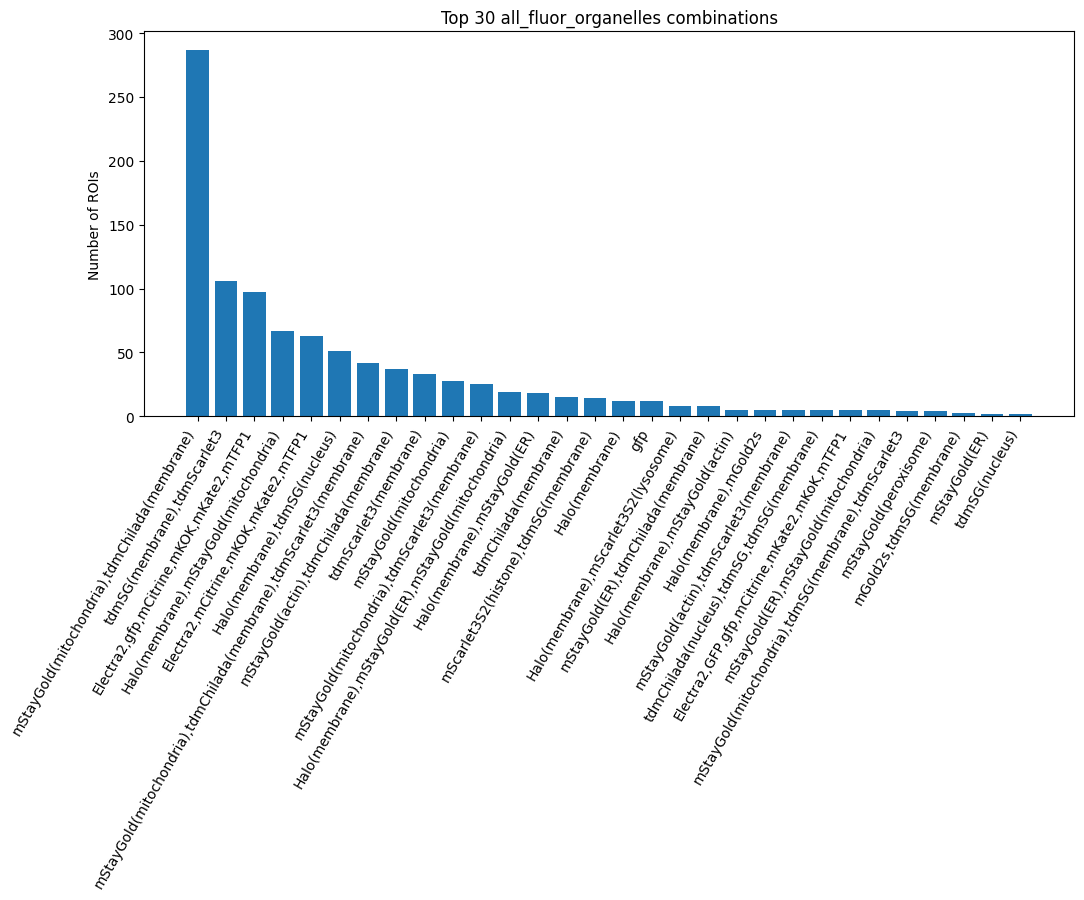

In [178]:
# CELL QA6: Plot counts of all_fluor_organelles combinations

import matplotlib.pyplot as plt
import pandas as pd
import math

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

# get value counts for the fluor-organelle combos, ignore blanks
fluor_combo_counts = (
    df.loc[~df["all_fluor_organelles"].apply(is_blank), "all_fluor_organelles"]
      .value_counts()
)

print("Unique fluor(organelle) combinations (top 50):")
display(fluor_combo_counts.head(50))

# Plot top N fluor-organelle combos as-is
topN = 30
top = fluor_combo_counts.head(topN)

plt.figure(figsize=(12, 5))
plt.bar(top.index, top.values)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Number of ROIs")
plt.title(f"Top {topN} all_fluor_organelles combinations")
plt.tight_layout()
plt.show()

In [179]:
# CELL QA_FUSIONS_VS_ORGANELLES: systematically find suspicious rows

import math
from collections import Counter

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    s = str(val).strip()
    return not s or s.lower() == "nan"

def count_items(val: object) -> int:
    if is_blank(val):
        return 0
    s = str(val).replace(";", ",")
    return sum(1 for t in s.split(",") if t.strip())

# --- (re)compute fusion/tag counts if needed ---

if "n_genotype_fusions" not in df.columns or "n_treatment_fusions" not in df.columns:
    df["n_genotype_fusions"]  = df.get("genotype_marker_fusion_labels", "").apply(count_items)
    df["n_treatment_fusions"] = df.get("treatment_marker_fusion_labels", "").apply(count_items)
    df["n_total_fusions"]     = df["n_genotype_fusions"] + df["n_treatment_fusions"]

if "n_unique_organelles" not in df.columns:
    df["n_unique_organelles"] = df.get("all_unique_organelles", "").apply(count_items)

# count fluor-loc labels (each fluor(organelle) entry)
df["n_genotype_fluor_locs"]  = df.get("genotype_marker_fluor_loc_labels", "").apply(count_items)
df["n_treatment_fluor_locs"] = df.get("treatment_marker_fluor_loc_labels", "").apply(count_items)
df["n_total_fluor_locs"]     = df["n_genotype_fluor_locs"] + df["n_treatment_fluor_locs"]

# --- define mismatch conditions ---

mask_fusions_no_orgs = (df["n_total_fusions"] > 0) & (df["n_unique_organelles"] == 0)
mask_orgs_no_fusions = (df["n_total_fusions"] == 0) & (df["n_unique_organelles"] > 0)

# more subtle: lots of organelles but too few fluor-loc labels or vice versa
mask_more_fluor_than_orgs = (df["n_total_fluor_locs"] > df["n_unique_organelles"]) & (df["n_unique_organelles"] > 0)
mask_more_orgs_than_fluor = (df["n_unique_organelles"] > df["n_total_fluor_locs"]) & (df["n_total_fluor_locs"] > 0)

suspect = df[mask_fusions_no_orgs | mask_orgs_no_fusions | mask_more_fluor_than_orgs | mask_more_orgs_than_fluor].copy()

print(f"[QA_FUSIONS_VS_ORGANELLES] total ROIs: {len(df)}")
print(f"  fusions>0 but n_unique_organelles==0: {mask_fusions_no_orgs.sum()}")
print(f"  n_unique_organelles>0 but fusions==0: {mask_orgs_no_fusions.sum()}")
print(f"  n_total_fluor_locs > n_unique_organelles: {mask_more_fluor_than_orgs.sum()}")
print(f"  n_unique_organelles > n_total_fluor_locs: {mask_more_orgs_than_fluor.sum()}")
print(f"  total suspect rows: {suspect.shape[0]}")

# quick grouped view by experiment
summary_suspect = (
    suspect.groupby("date_experiment", dropna=False)
           .agg(
               n_rois=("roi_dir", "count"),
               examples=("all_fluor_organelles", lambda x: sorted(set(list(x)[:3]))),
           )
           .sort_values("n_rois", ascending=False)
)

print("\n[QA_FUSIONS_VS_ORGANELLES] suspect experiments (top 40):")
display(summary_suspect.head(40))

# and show a few raw rows so we can eyeball them
print("\n[QA_FUSIONS_VS_ORGANELLES] example suspect rows:")
display(
    suspect[[
        "roi_dir",
        "date_experiment",
        "genotype_base_codes",
        "treatment_plasmid_base_codes",
        "genotype_marker_fusion_labels",
        "genotype_marker_localizations",
        "treatment_marker_fusion_labels",
        "treatment_marker_localizations",
        "all_unique_organelles",
        "all_fluor_organelles",
        "n_total_fusions",
        "n_total_fluor_locs",
        "n_unique_organelles",
    ]].head(30)
)

[QA_FUSIONS_VS_ORGANELLES] total ROIs: 1077
  fusions>0 but n_unique_organelles==0: 182
  n_unique_organelles>0 but fusions==0: 0
  n_total_fluor_locs > n_unique_organelles: 205
  n_unique_organelles > n_total_fluor_locs: 0
  total suspect rows: 387

[QA_FUSIONS_VS_ORGANELLES] suspect experiments (top 40):


,n_rois,examples
date_experiment,,
20250917_mem-mito,42,"[mStayGold(mitochondria),tdmChilada(membrane),..."
20250624_skittlez_Chris_x_Liam,34,"[Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1]"
20250606_skittlez,23,"[Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1]"
20250618_skittlez,23,"[Electra2,mCitrine,mKOK,mKate2,mTFP1]"
20250529_skittlez,22,"[Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1]"
20250605_skittlez,21,"[Electra2,mCitrine,mKOK,mKate2,mTFP1]"
20251020_mem-histone,20,"[tdmSG(membrane),tdmScarlet3]"
20250603_skittlez,18,"[Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1]"
20250915_mem-mito,18,"[Halo(membrane),mStayGold(mitochondria)]"



[QA_FUSIONS_VS_ORGANELLES] example suspect rows:


,roi_dir,date_experiment,genotype_base_codes,treatment_plasmid_base_codes,genotype_marker_fusion_labels,genotype_marker_localizations,treatment_marker_fusion_labels,treatment_marker_localizations,all_unique_organelles,all_fluor_organelles,n_total_fusions,n_total_fluor_locs,n_unique_organelles
2,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,pDQM005,pDQM140,tdmSG::2xLynk(N),membrane,mGold2s,None,membrane,"mGold2s,tdmSG(membrane)",2,2,1
3,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,pDQM005,pDQM140,tdmSG::2xLynk(N),membrane,mGold2s,None,membrane,"mGold2s,tdmSG(membrane)",2,2,1
4,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,pDQM005,pDQM140,tdmSG::2xLynk(N),membrane,mGold2s,None,membrane,"mGold2s,tdmSG(membrane)",2,2,1
5,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,Swinburne,pDQM140,Halo,membrane,mGold2s,None,membrane,"Halo(membrane),mGold2s",1,2,0
6,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,Swinburne,pDQM140,Halo,membrane,mGold2s,None,membrane,"Halo(membrane),mGold2s",1,2,0
7,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,Swinburne,pDQM140,Halo,membrane,mGold2s,None,membrane,"Halo(membrane),mGold2s",1,2,0
8,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,Swinburne,pDQM140,Halo,membrane,mGold2s,None,membrane,"Halo(membrane),mGold2s",1,2,0
9,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,Swinburne,pDQM140,Halo,membrane,mGold2s,None,membrane,"Halo(membrane),mGold2s",1,2,0
11,/clusterfs/vast/abcabc/Korra_Foundation/202505...,20250513_skittles,None,"pDQM034,pDQM036",None,None,"Electra2,mCitrine,mKOK,mKate2,mTFP1",None,None,"Electra2,mCitrine,mKOK,mKate2,mTFP1",5,5,0
93,/clusterfs/vast/abcabc/Korra_Foundation/202505...,20250529_skittlez,"pDQM034,pDQM059",None,"Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1",None,None,None,None,"Electra2,gfp,mCitrine,mKOK,mKate2,mTFP1",6,6,0
